 **Nota importante**

**Cargar el subir el dataset antes de correr el codigo**

Cargamos librerias necesarias

In [ ]:
#CARGAR LIBRERIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


Carga el Dataset y ajuste de tipo de variables y estructuras

In [ ]:
df = pd.read_csv(
    "/content/DATASET_COMPLETO_3.0.csv",
    encoding='latin-1',
    sep=';'
)

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace('\ufeff', '')
    .str.replace('\n', '')
    .str.upper()
)

In [ ]:
print(df.columns.tolist())

['ID_TRANSACCION', 'FECHA', 'CREDITOS']


In [ ]:
df['CREDITOS'] = (
    df['CREDITOS']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)


In [ ]:
df['FECHA'] = pd.to_datetime(
    df['FECHA'],
    dayfirst=True,
    format='mixed',
    errors='coerce'
)

Revisar como quedo la informacion

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239855 entries, 0 to 239854
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_TRANSACCION  239855 non-null  int64         
 1   FECHA           239855 non-null  datetime64[ns]
 2   CREDITOS        239855 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 5.5 MB


Limpieza de datos, y agrupar por meses, se renombre CREDITOS por VENTAS

In [ ]:
df = df.dropna(subset=['FECHA'])

df_mensual = (
    df
    .set_index('FECHA')
    .resample('M')['CREDITOS']
    .sum()
    .reset_index()
    .rename(columns={'CREDITOS': 'VENTAS'})
)


In [ ]:
#ESTADISTICAS
df_mensual.describe()

,FECHA,VENTAS
count,316,3.160000e+02
mean,2013-03-16 00:50:07.594936832,1.017320e+07
min,2000-01-31 00:00:00,4.780084e+06
25%,2006-08-23 06:00:00,6.847850e+06
50%,2013-03-15 12:00:00,9.397889e+06
75%,2019-10-07 18:00:00,1.298257e+07
max,2026-04-30 00:00:00,1.844015e+07
std,NaN,3.762892e+06


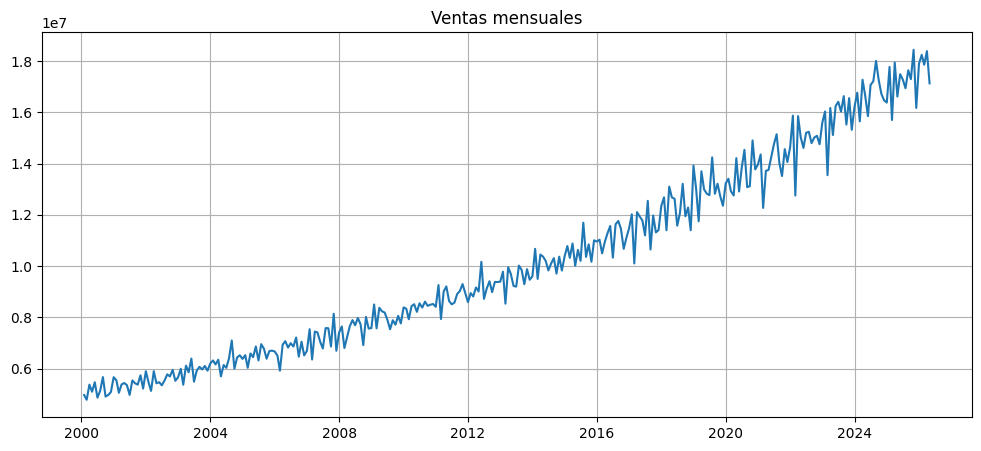

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_mensual['FECHA'], df_mensual['VENTAS'])
plt.title("Ventas mensuales")
plt.grid()
plt.show()

Revision de posibles outhliers

In [ ]:
Q1 = df_mensual['VENTAS'].quantile(0.25)
Q3 = df_mensual['VENTAS'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_mensual[
    (df_mensual['VENTAS'] < lower) |
    (df_mensual['VENTAS'] > upper)
].sort_values('VENTAS', ascending=False)

outliers

,FECHA,VENTAS


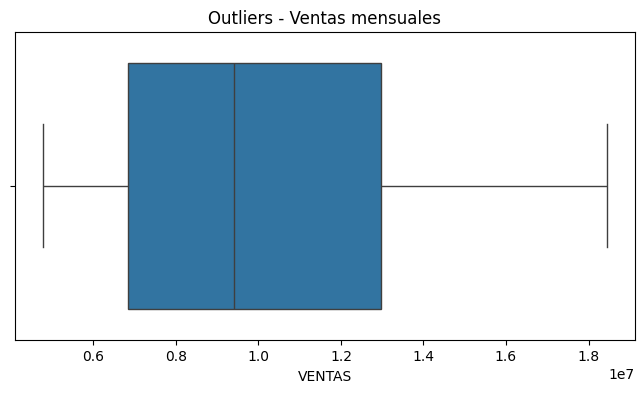

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(x=df_mensual['VENTAS'])
plt.title("Outliers - Ventas mensuales")
plt.show()

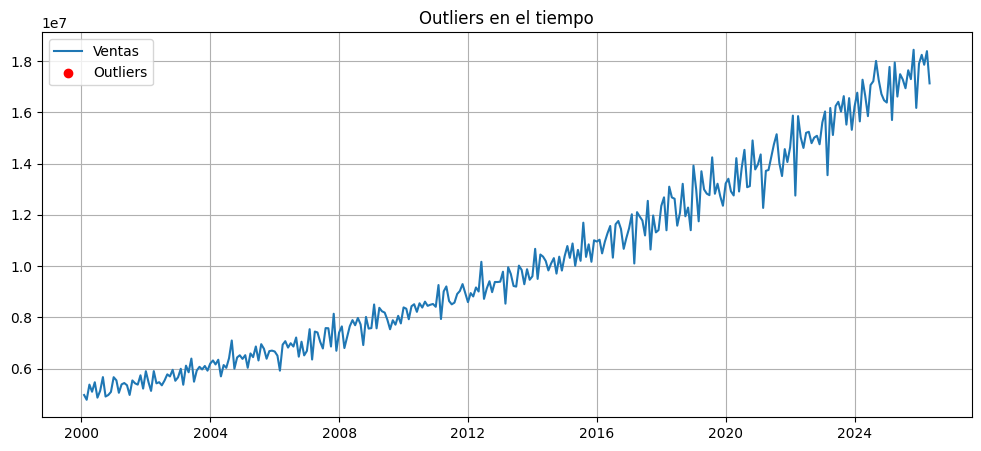

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df_mensual['FECHA'], df_mensual['VENTAS'], label='Ventas')

plt.scatter(
    outliers['FECHA'],
    outliers['VENTAS'],
    color='red',
    label='Outliers'
)

plt.legend()
plt.title("Outliers en el tiempo")
plt.grid()
plt.show()

***El Problema***

En meses recientes trabajamos con una compañía de comestibles que estaba interesada en predecir el comportamiento de las ventas (en pesos) de su productos estrella. Fuimos contratados para generar un modelo que permita pronosticar las ventas del siguiente mes de SU producto. La base de datos disponible en el archivo DATASET_COMPLETO_2.0.csv tiene la información de cada uno de los productos desde enero 2020.

Su misión es encontrar el mejor modelo para pronosticar cada una de las series.

## **4. Protocolos de evaluación**

**Backtesting con Walk-Forward Validation**</br>
Para evaluar el rendimiento de los modelos predictivos en esta serie temporal, implementaremos un protocolo de backtesting basado en walk-forward validation, aplicando dos variantes: ventana móvil y ventana recursiva.

### **4.1. Walk-Forward Validation con Ventana Recursiva**
El enfoque de ventana recursiva emplea un conjunto de entrenamiento que se expande progresivamente a medida que avanzamos en el tiempo. En cada iteración, el modelo se reentrena incluyendo todos los datos históricos disponibles hasta ese punto, sin eliminar ningún dato anterior. Este método es adecuado para capturar tanto patrones a corto como a largo plazo, ya que utiliza toda la información histórica para hacer predicciones, proporcionando así una visión más completa de la serie temporal.

![Backtesting con Reentrenamiento](https://cienciadedatos.net/images/backtesting_refit.gif)
<sub>*(Diagrama de time series backtesting con un tamaño inicial de entrenamiento de 10 observaciones, un horizonte de predicción de 3 steps y reentrenamiento en cada iteración.)*</sub>

### **4.2. Walk-Forward Validation con Ventana Móvil**
En el enfoque de ventana móvil, el modelo se entrena utilizando una ventana de datos de tamaño constante que se desplaza a lo largo del tiempo. En cada iteración, los datos más antiguos se eliminan y se añaden los datos más recientes, manteniendo un conjunto de entrenamiento de tamaño fijo. Este método es ideal para capturar cambios recientes en la serie temporal, ya que prioriza la información más actual y permite una rápida adaptación a nuevos patrones.

![Backtesting con reentrenamiento y tamaño de entrenamiento constante](https://cienciadedatos.net/images/backtesting_refit_fixed_train_size.gif)
<sub>*(Diagrama de time series backtesting con un tamaño inicial de entrenamiento de 10 observaciones, un horizonte de predicción de 3 steps y set de entrenamiento con tamaño constante.)*</sub>

Fuente: [Skforecast: forecasting series temporales con Python, Machine Learning y Scikit-learn](https://cienciadedatos.net/documentos/py27-forecasting-series-temporales-python-scikitlearn).

**MODELADO**

In [ ]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error
from itertools import product
!pip install bayesian-optimization
from bayes_opt import BayesianOptimization
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import itertools
from pandas.tseries.offsets import MonthBegin
from statsmodels.sandbox.stats.runs import runstest_1samp
import pylab as py
from scipy import stats
import seaborn as sns
!pip install pmdarima
from pmdarima.arima import auto_arima
from pmdarima.utils import acf,pacf
from pmdarima.arima import ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.sandbox.stats.runs import runstest_1samp # prueba de rachas de Wald y Wolfowitz
from datetime import datetime
from dateutil.relativedelta import relativedelta
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf


import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

# Suprimir los warnings específicos de statsmodels
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.8 MB/s eta 0:00:00


## **2. Carga de datos**
Empleando la información de las ventas en unidades de una mepresa de comestibles. Las ventas estan expresadas en unidades mensuales desde enero de 2020, y se tiene los dos productos estrellas de la empresa.

In [ ]:
data = df_mensual

(316, 2)


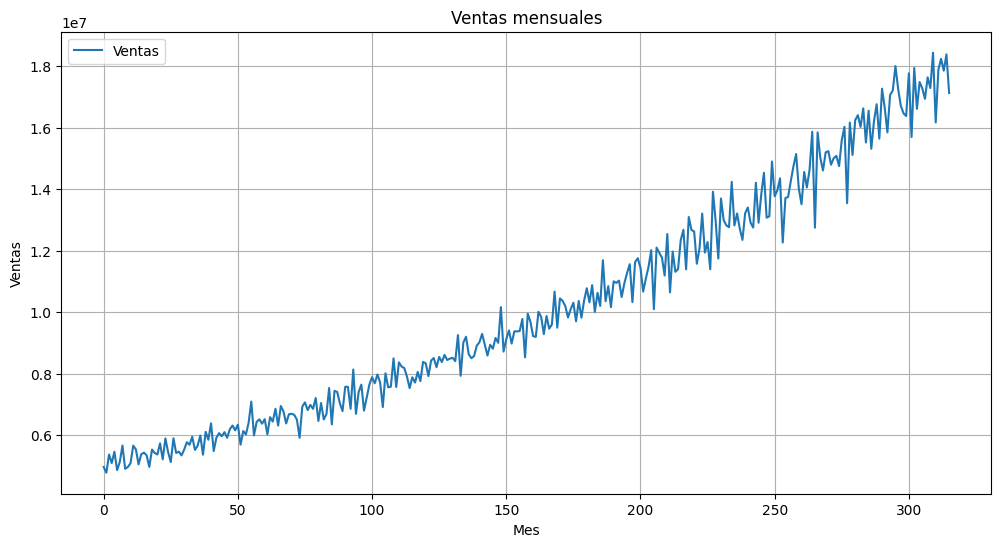

In [ ]:
# tamaño del dataset
print(data.shape)

# gráfico de la serie mensual
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.title("Ventas mensuales")
plt.xlabel("Mes")
plt.ylabel("Ventas")

plt.plot(data['VENTAS'], label="Ventas")

plt.legend()
plt.grid()
plt.show()

In [ ]:
print(data.shape)
print(data.head())
print(data['VENTAS'].isna().sum())

(316, 2)
       FECHA     VENTAS
0 2000-01-31  4966041.0
1 2000-02-29  4780084.0
2 2000-03-31  5371961.0
3 2000-04-30  5093745.0
4 2000-05-31  5464223.0
0


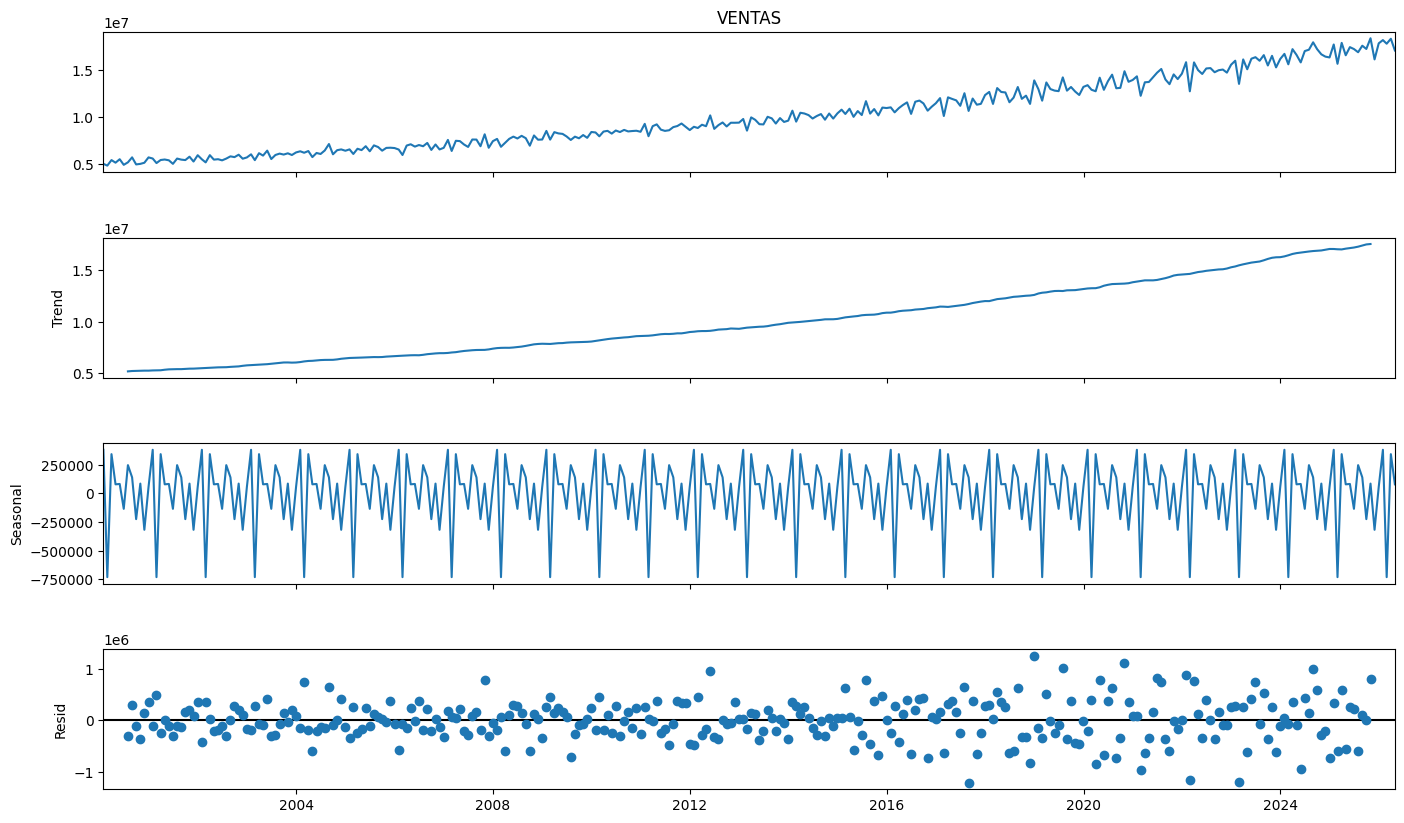

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# preparar data correctamente
data = df_mensual.set_index('FECHA')

# descomposición
td_componentes = seasonal_decompose(
    data['VENTAS'],
    model='additive',
    period=12
)

# graficar
fig = td_componentes.plot()
fig.set_size_inches((16, 9))
plt.show()

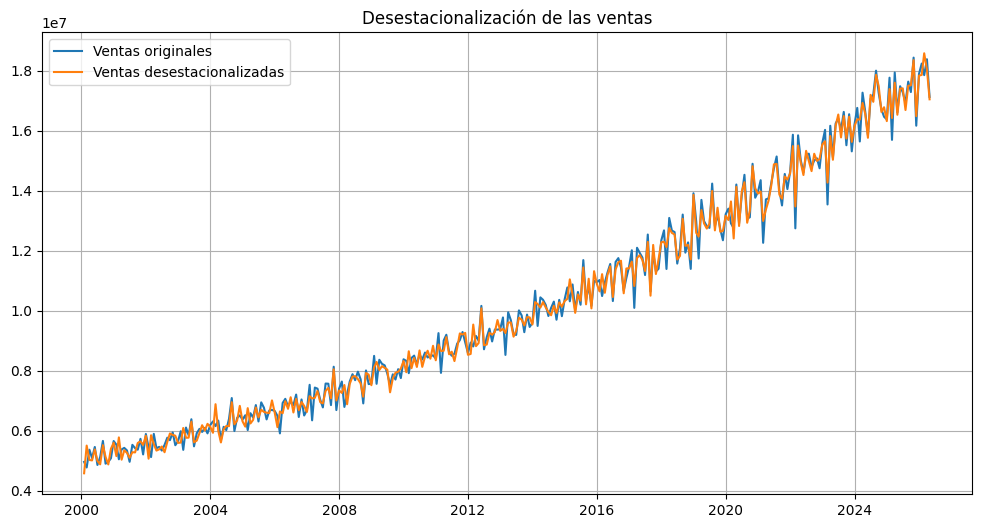

In [ ]:
# Asegurar que trabajas con serie
serie = data['VENTAS']

# Desestacionalización (modelo aditivo)
td_desestacionalizada = serie - td_componentes.seasonal

# Gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.title("Desestacionalización de las ventas")

plt.plot(serie, label="Ventas originales")
plt.plot(td_desestacionalizada, label="Ventas desestacionalizadas")

plt.legend()
plt.grid()
plt.show()

## **5. Modelado**

### **5.1. Suavizacion Exponencial Simple, Suavizacion Exponencial Lineal (Holt) y Suavizacion Exponencial Lineal de Winters (Holt-Winters)**

Probando: error=add, trend=add, seasonal=add, damped=True
Probando: error=add, trend=add, seasonal=add, damped=False
Probando: error=add, trend=add, seasonal=mul, damped=True
Probando: error=add, trend=add, seasonal=mul, damped=False
Probando: error=add, trend=add, seasonal=None, damped=True
Probando: error=add, trend=add, seasonal=None, damped=False
Probando: error=add, trend=mul, seasonal=add, damped=True
Probando: error=add, trend=mul, seasonal=add, damped=False
Probando: error=add, trend=mul, seasonal=mul, damped=True
Probando: error=add, trend=mul, seasonal=mul, damped=False
Probando: error=add, trend=mul, seasonal=None, damped=True
Probando: error=add, trend=mul, seasonal=None, damped=False
Probando: error=add, trend=None, seasonal=add, damped=True
Probando: error=add, trend=None, seasonal=add, damped=False
Probando: error=add, trend=None, seasonal=mul, damped=True
Probando: error=add, trend=None, seasonal=mul, damped=False
Probando: error=add, trend=None, seasonal=None, damped=T

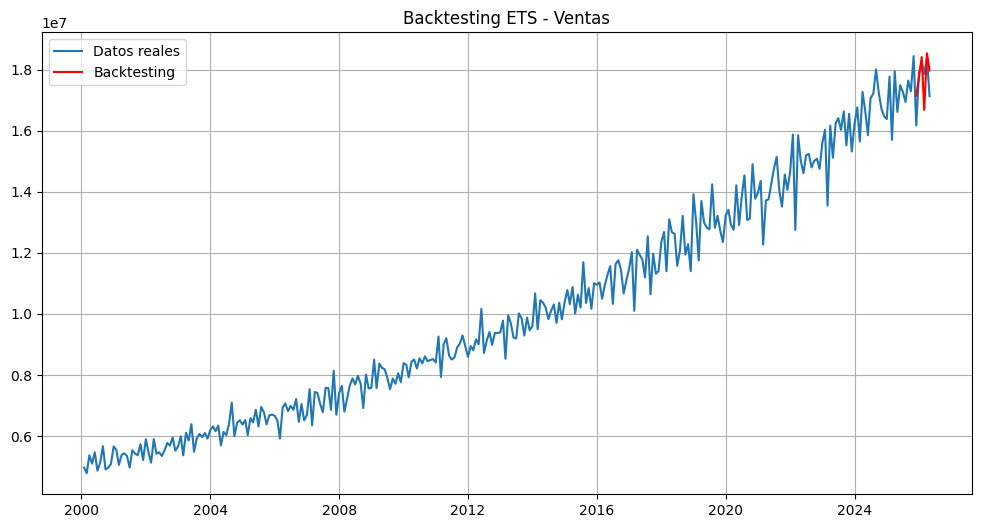

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import product
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# 1. Preparar datos
# =========================
data = df_mensual.set_index('FECHA')

# asegurar frecuencia mensual
y = data['VENTAS'].asfreq('M')

# eliminar nulos
y = y.dropna()

# evitar valores <= 0 para modelos multiplicativos
y = y[y > 0]

# =========================
# 2. Parámetros
# =========================
steps = 1
n_backtesting = 6

# tipo de validación
tipo_backtesting = "Ventana Recursiva"

error_options = ["add", "mul"]
trend_options = ["add", "mul", None]
seasonal_options = ["add", "mul", None]

# ayuda a mejorar ajuste y R2
damped_options = [True, False]

param_grid = list(product(
    error_options,
    trend_options,
    seasonal_options,
    damped_options
))

# =========================
# 3. Función backtesting
# =========================
def backtesting_forecaster(
    y,
    initial_train_size,
    steps,
    error,
    trend,
    seasonal,
    damped_trend
):

    # evitar configuración inválida
    if trend is None and damped_trend:
        return None, None, None, None

    predictions = []
    true_values = []

    for i in range(initial_train_size, len(y) - steps + 1, steps):

        # =========================
        # VENTANA RECURSIVA
        # =========================
        train_y = y[:i]

        test_y = y[i:i+steps]

        try:

            model = ETSModel(
                endog=train_y,
                error=error,
                trend=trend,
                seasonal=seasonal,
                damped_trend=damped_trend,
                seasonal_periods=12
            )

            fit = model.fit(
                disp=False,
                optimized=True
            )

            pred = fit.forecast(steps)

            predictions.extend(pred)
            true_values.extend(test_y)

        except:
            return None, None, None, None

    # validar predicciones
    if len(predictions) == 0:
        return None, None, None, None

    # métricas
    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)

    return rmse, mae, r2, predictions

# =========================
# 4. Búsqueda hiperparámetros
# =========================
results = []

best_rmse = float("inf")
best_r2 = -float("inf")

best_params = None
best_predictions = None

for error, trend, seasonal, damped_trend in param_grid:

    print(
        f"Probando: "
        f"error={error}, "
        f"trend={trend}, "
        f"seasonal={seasonal}, "
        f"damped={damped_trend}"
    )

    rmse, mae, r2, preds = backtesting_forecaster(
        y=y,
        initial_train_size=len(y) - n_backtesting,
        steps=steps,
        error=error,
        trend=trend,
        seasonal=seasonal,
        damped_trend=damped_trend
    )

    # saltar combinaciones inválidas
    if rmse is None:
        continue

    # nombre del modelo
    model_name = (
        f"ETS("
        f"Error={error}, "
        f"Trend={trend}, "
        f"Seasonal={seasonal}, "
        f"Damped={damped_trend}"
        f")"
    )

    # guardar resultados
    results.append({
        "Modelo": model_name,
        "Tipo_Backtesting": tipo_backtesting,
        "Error": error,
        "Trend": trend,
        "Seasonal": seasonal,
        "Damped": damped_trend,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    # priorizar mejor R2
    if r2 > best_r2:

        best_r2 = r2
        best_rmse = rmse

        best_params = (
            error,
            trend,
            seasonal,
            damped_trend
        )

        best_predictions = preds

# =========================
# 5. Resultados
# =========================
results_df = pd.DataFrame(results)

# ordenar por mejor R2
results_df = results_df.sort_values(
    by=["R2", "RMSE"],
    ascending=[False, True]
)

print("\n============================")
print("MEJORES HIPERPARÁMETROS")
print("============================")

print(best_params)

print(f"\nRMSE : {best_rmse:.4f}")
print(f"R2   : {best_r2:.4f}")

# =========================
# 6. Guardar mejor resultado
# =========================
best_result_df = results_df.head(1)

best_result_df.to_csv(
    "mejor_modelo_ets.csv",
    index=False
)

print("\nCSV GUARDADO:")
print("mejor_modelo_ets.csv")

# =========================
# 7. Gráfico
# =========================
plt.figure(figsize=(12, 6))

plt.plot(
    y.index,
    y.values,
    label='Datos reales'
)

# índice de predicciones
pred_index = y.index[-len(best_predictions):]

plt.plot(
    pred_index,
    best_predictions,
    label='Backtesting',
    color='red'
)

plt.title("Backtesting ETS - Ventas")
plt.legend()
plt.grid()

plt.show()

### **a. Ventana recursiva**

In [ ]:
results_df
results_df.style.bar(subset=['RMSE'], align='mid', color=['#d65f5f','#5fba7d'])

,Modelo,Tipo_Backtesting,Error,Trend,Seasonal,Damped,RMSE,MAE,R2
22,"ETS(Error=mul, Trend=mul, Seasonal=add, Damped=False)",Ventana Recursiva,mul,mul,add,False,720362.519585,576025.069362,0.096134
7,"ETS(Error=add, Trend=mul, Seasonal=add, Damped=False)",Ventana Recursiva,add,mul,add,False,731875.602313,584202.663608,0.067011
1,"ETS(Error=add, Trend=add, Seasonal=add, Damped=False)",Ventana Recursiva,add,add,add,False,750438.033486,604711.661707,0.019085
21,"ETS(Error=mul, Trend=mul, Seasonal=add, Damped=True)",Ventana Recursiva,mul,mul,add,True,753809.268296,569734.538624,0.010251
15,"ETS(Error=mul, Trend=add, Seasonal=add, Damped=True)",Ventana Recursiva,mul,add,add,True,754301.126518,579443.495977,0.008959
24,"ETS(Error=mul, Trend=mul, Seasonal=mul, Damped=False)",Ventana Recursiva,mul,mul,mul,False,758273.567766,584732.110328,-0.001506
0,"ETS(Error=add, Trend=add, Seasonal=add, Damped=True)",Ventana Recursiva,add,add,add,True,758704.305870,591045.197372,-0.002645
6,"ETS(Error=add, Trend=mul, Seasonal=add, Damped=True)",Ventana Recursiva,add,mul,add,True,761339.249864,586220.138484,-0.009621
16,"ETS(Error=mul, Trend=add, Seasonal=add, Damped=False)",Ventana Recursiva,mul,add,add,False,763751.819090,622833.722531,-0.016030
19,"ETS(Error=mul, Trend=add, Seasonal=None, Damped=True)",Ventana Recursiva,mul,add,None,True,769671.449117,628377.420373,-0.031841


con optimizazción Bayesiana:

|   iter    |  target   |   error   |   trend   | seasonal  |
-------------------------------------------------------------
Probando: add, None, mul → RMSE=892651.30
| 1         | -892651.2 | 0.3745401 | 1.9014286 | 1.4639878 |
Probando: mul, add, add → RMSE=763751.82
| 2         | -763751.8 | 0.5986584 | 0.3120372 | 0.3119890 |
Probando: add, None, mul → RMSE=892651.30
| 3         | -892651.2 | 0.0580836 | 1.7323522 | 1.2022300 |
Probando: mul, add, None → RMSE=817177.25
| 4         | -817177.2 | 0.7080725 | 0.0411689 | 1.9398197 |
Probando: mul, add, add → RMSE=763751.82
| 5         | -763751.8 | 0.8324426 | 0.4246782 | 0.3636499 |
Probando: mul, add, add → RMSE=763751.82
| 6         | -763751.8 | 1.0       | 0.0       | 0.0       |
Probando: mul, mul, add → RMSE=720362.52
| 7         | -720362.5 | 1.0       | 1.3531947 | 0.0       |
Probando: mul, None, add → RMSE=803748.11
| 8         | -803748.1 | 1.0       | 2.0       | 0.0       |
Probando: add, mul, add → RMSE=731875.60
| 9    

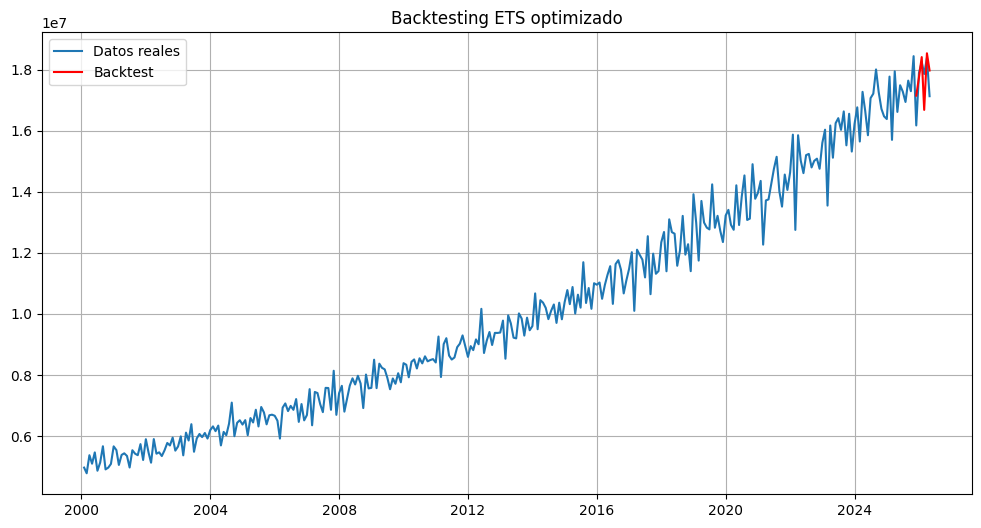

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bayes_opt import BayesianOptimization
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error

# =========================
# 1. Preparar datos
# =========================
data = df_mensual.set_index('FECHA')
y = data['VENTAS'].asfreq('M')

# Validación
y = y.interpolate()  # por si hay huecos

steps = 1
n_backtesting = 6

# =========================
# 2. Backtesting robusto
# =========================
def backtesting_forecaster(y, initial_train_size, steps, error, trend, seasonal):
    predictions = []
    true_values = []

    for i in range(initial_train_size, len(y) - steps + 1, steps):
        train_y = y[:i]
        test_y = y[i:i+steps]

        try:
            model = ETSModel(
                endog=train_y,
                error=error,
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=12
            )

            fit = model.fit(disp=False)
            pred = fit.forecast(steps)

            predictions.extend(pred)
            true_values.extend(test_y)

        except:
            return None  # combinación inválida

    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    return rmse

# =========================
# 3. Función objetivo
# =========================
def objective_function(error, trend, seasonal):
    error = int(round(error))
    trend = int(round(trend))
    seasonal = int(round(seasonal))

    error_options = ['add', 'mul']
    trend_options = ['add', 'mul', None]
    seasonal_options = ['add', 'mul', None]

    error_param = error_options[error]
    trend_param = trend_options[trend]
    seasonal_param = seasonal_options[seasonal]

    rmse = backtesting_forecaster(
        y=y,
        initial_train_size=len(y) - n_backtesting,
        steps=steps,
        error=error_param,
        trend=trend_param,
        seasonal=seasonal_param
    )

    if rmse is None or np.isnan(rmse):
        return -1e10  # penalizar combinaciones inválidas

    print(f"Probando: {error_param}, {trend_param}, {seasonal_param} → RMSE={rmse:.2f}")

    return -rmse  # maximiza negativo

# =========================
# 4. Optimización bayesiana
# =========================
pbounds = {
    'error': (0, 1),
    'trend': (0, 2),
    'seasonal': (0, 2)
}

optimizer = BayesianOptimization(
    f=objective_function,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(init_points=5, n_iter=25)

# =========================
# 5. Mejores parámetros
# =========================
best_params = optimizer.max['params']

best_error = ['add', 'mul'][round(best_params['error'])]
best_trend = ['add', 'mul', None][round(best_params['trend'])]
best_seasonal = ['add', 'mul', None][round(best_params['seasonal'])]

print("\nMejores hiperparámetros:")
print(best_error, best_trend, best_seasonal)

# =========================
# 6. Backtest final con mejores params
# =========================
def backtesting_with_preds(y, initial_train_size, steps, error, trend, seasonal):
    predictions = []
    true_values = []

    for i in range(initial_train_size, len(y) - steps + 1, steps):
        train_y = y[:i]
        test_y = y[i:i+steps]

        model = ETSModel(
            endog=train_y,
            error=error,
            trend=trend,
            seasonal=seasonal,
            seasonal_periods=12
        )

        fit = model.fit(disp=False)
        pred = fit.forecast(steps)

        predictions.extend(pred)
        true_values.extend(test_y)

    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    return rmse, predictions

best_rmse, best_predictions = backtesting_with_preds(
    y=y,
    initial_train_size=len(y) - n_backtesting,
    steps=steps,
    error=best_error,
    trend=best_trend,
    seasonal=best_seasonal
)

print(f"Mejor RMSE: {best_rmse:.2f}")

# =========================
# 7. Gráfico
# =========================
plt.figure(figsize=(12,6))

plt.plot(y, label='Datos reales')

pred_index = y.index[-len(best_predictions):]
plt.plot(pred_index, best_predictions, color='red', label='Backtest')

plt.legend()
plt.grid()
plt.title("Backtesting ETS optimizado")
plt.show()

|   iter    |  target   |   error   |   trend   | seasonal  |
-------------------------------------------------------------
Probando: add, None, mul → RMSE=892651.30 | R2=-0.3879
| 1         | -0.387923 | 0.3745401 | 1.9014286 | 1.4639878 |
Probando: mul, add, add → RMSE=763751.82 | R2=-0.0160
| 2         | -0.016029 | 0.5986584 | 0.3120372 | 0.3119890 |
Probando: add, None, mul → RMSE=892651.30 | R2=-0.3879
| 3         | -0.387923 | 0.0580836 | 1.7323522 | 1.2022300 |
Probando: mul, add, None → RMSE=817177.25 | R2=-0.1631
| 4         | -0.163146 | 0.7080725 | 0.0411689 | 1.9398197 |
Probando: mul, add, add → RMSE=763751.82 | R2=-0.0160
| 5         | -0.016029 | 0.8324426 | 0.4246782 | 0.3636499 |
Probando: mul, add, add → RMSE=763751.82 | R2=-0.0160
| 6         | -0.016029 | 1.0       | 0.0       | 0.0       |
Probando: mul, mul, add → RMSE=720362.52 | R2=0.0961
| 7         | 0.0961338 | 1.0       | 1.3514785 | 0.0       |
Probando: mul, None, add → RMSE=803748.11 | R2=-0.1252
| 8    

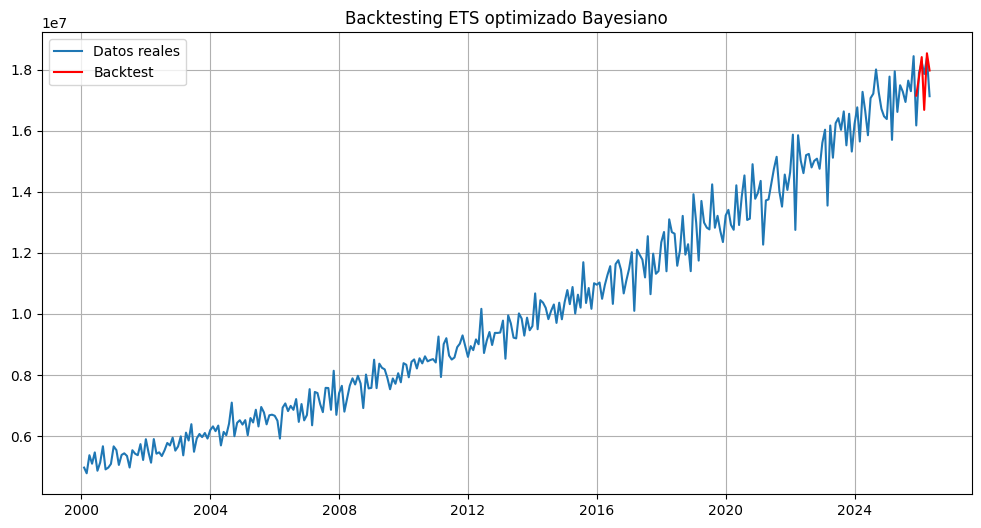

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bayes_opt import BayesianOptimization
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# 1. Preparar datos
# =========================
data = df_mensual.set_index('FECHA')

y = data['VENTAS'].asfreq('M')

# Validación
y = y.interpolate()

# evitar problemas multiplicativos
y = y[y > 0]

steps = 1
n_backtesting = 6

# tipo backtesting
tipo_backtesting = "Ventana Recursiva"

# =========================
# 2. Backtesting robusto
# =========================
def backtesting_forecaster(
    y,
    initial_train_size,
    steps,
    error,
    trend,
    seasonal
):

    predictions = []
    true_values = []

    for i in range(initial_train_size, len(y) - steps + 1, steps):

        # =========================
        # VENTANA RECURSIVA
        # =========================
        train_y = y[:i]

        test_y = y[i:i+steps]

        try:

            model = ETSModel(
                endog=train_y,
                error=error,
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=12
            )

            fit = model.fit(disp=False)

            pred = fit.forecast(steps)

            predictions.extend(pred)
            true_values.extend(test_y)

        except:
            return None, None, None

    # validar resultados
    if len(predictions) == 0:
        return None, None, None

    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)

    return rmse, mae, r2

# =========================
# 3. Función objetivo
# =========================
def objective_function(error, trend, seasonal):

    error = int(round(error))
    trend = int(round(trend))
    seasonal = int(round(seasonal))

    error_options = ['add', 'mul']
    trend_options = ['add', 'mul', None]
    seasonal_options = ['add', 'mul', None]

    error_param = error_options[error]
    trend_param = trend_options[trend]
    seasonal_param = seasonal_options[seasonal]

    rmse, mae, r2 = backtesting_forecaster(
        y=y,
        initial_train_size=len(y) - n_backtesting,
        steps=steps,
        error=error_param,
        trend=trend_param,
        seasonal=seasonal_param
    )

    # penalizar combinaciones inválidas
    if rmse is None or np.isnan(rmse):
        return -1e10

    print(
        f"Probando: "
        f"{error_param}, "
        f"{trend_param}, "
        f"{seasonal_param} "
        f"→ RMSE={rmse:.2f} | R2={r2:.4f}"
    )

    # maximizar R2
    return r2

# =========================
# 4. Optimización bayesiana
# =========================
pbounds = {
    'error': (0, 1),
    'trend': (0, 2),
    'seasonal': (0, 2)
}

optimizer = BayesianOptimization(
    f=objective_function,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=25
)

# =========================
# 5. Mejores parámetros
# =========================
best_params = optimizer.max['params']

best_error = ['add', 'mul'][round(best_params['error'])]
best_trend = ['add', 'mul', None][round(best_params['trend'])]
best_seasonal = ['add', 'mul', None][round(best_params['seasonal'])]

print("\n============================")
print("MEJORES HIPERPARÁMETROS")
print("============================")

print(best_error, best_trend, best_seasonal)

# =========================
# 6. Backtest final
# =========================
def backtesting_with_preds(
    y,
    initial_train_size,
    steps,
    error,
    trend,
    seasonal
):

    predictions = []
    true_values = []

    for i in range(initial_train_size, len(y) - steps + 1, steps):

        train_y = y[:i]
        test_y = y[i:i+steps]

        model = ETSModel(
            endog=train_y,
            error=error,
            trend=trend,
            seasonal=seasonal,
            seasonal_periods=12
        )

        fit = model.fit(disp=False)

        pred = fit.forecast(steps)

        predictions.extend(pred)
        true_values.extend(test_y)

    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)

    return rmse, mae, r2, predictions

best_rmse, best_mae, best_r2, best_predictions = backtesting_with_preds(
    y=y,
    initial_train_size=len(y) - n_backtesting,
    steps=steps,
    error=best_error,
    trend=best_trend,
    seasonal=best_seasonal
)

print(f"\nRMSE : {best_rmse:.4f}")
print(f"MAE  : {best_mae:.4f}")
print(f"R2   : {best_r2:.4f}")

# =========================
# 7. Crear dataframe resultado
# =========================
model_name = (
    f"ETS_BAYESIAN("
    f"Error={best_error}, "
    f"Trend={best_trend}, "
    f"Seasonal={best_seasonal}"
    f")"
)

best_result_df = pd.DataFrame([{
    "Modelo": model_name,
    "Optimizacion": "Bayesiana",
    "Tipo_Backtesting": tipo_backtesting,
    "Error": best_error,
    "Trend": best_trend,
    "Seasonal": best_seasonal,
    "RMSE": best_rmse,
    "MAE": best_mae,
    "R2": best_r2
}])

# =========================
# 8. Guardar o anexar CSV
# =========================
csv_file = "mejor_modelo_ets.csv"

try:

    existing_df = pd.read_csv(csv_file)

    updated_df = pd.concat(
        [existing_df, best_result_df],
        ignore_index=True
    )

    # ordenar por mejor R2
    updated_df = updated_df.sort_values(
        by=["R2", "RMSE"],
        ascending=[False, True]
    )

    updated_df.to_csv(
        csv_file,
        index=False
    )

except:

    best_result_df.to_csv(
        csv_file,
        index=False
    )

print("\nCSV ACTUALIZADO:")
print(csv_file)

# =========================
# 9. Gráfico
# =========================
plt.figure(figsize=(12,6))

plt.plot(
    y,
    label='Datos reales'
)

pred_index = y.index[-len(best_predictions):]

plt.plot(
    pred_index,
    best_predictions,
    color='red',
    label='Backtest'
)

plt.legend()
plt.grid()

plt.title("Backtesting ETS optimizado Bayesiano")

plt.show()

### **b. Ventana Movil**

Probando: error=add, trend=add, seasonal=add
Probando: error=add, trend=add, seasonal=mul
Probando: error=add, trend=add, seasonal=None
Probando: error=add, trend=mul, seasonal=add
Probando: error=add, trend=mul, seasonal=mul
Probando: error=add, trend=mul, seasonal=None
Probando: error=add, trend=None, seasonal=add
Probando: error=add, trend=None, seasonal=mul
Probando: error=add, trend=None, seasonal=None
Probando: error=mul, trend=add, seasonal=add
Probando: error=mul, trend=add, seasonal=mul
Probando: error=mul, trend=add, seasonal=None
Probando: error=mul, trend=mul, seasonal=add
Probando: error=mul, trend=mul, seasonal=mul
Probando: error=mul, trend=mul, seasonal=None
Probando: error=mul, trend=None, seasonal=add
Probando: error=mul, trend=None, seasonal=mul
Probando: error=mul, trend=None, seasonal=None

MEJORES HIPERPARÁMETROS
error=mul, trend=mul, seasonal=add

RMSE : 732912.9192
R2   : 0.0644

CSV ACTUALIZADO:
mejor_modelo_ets.csv


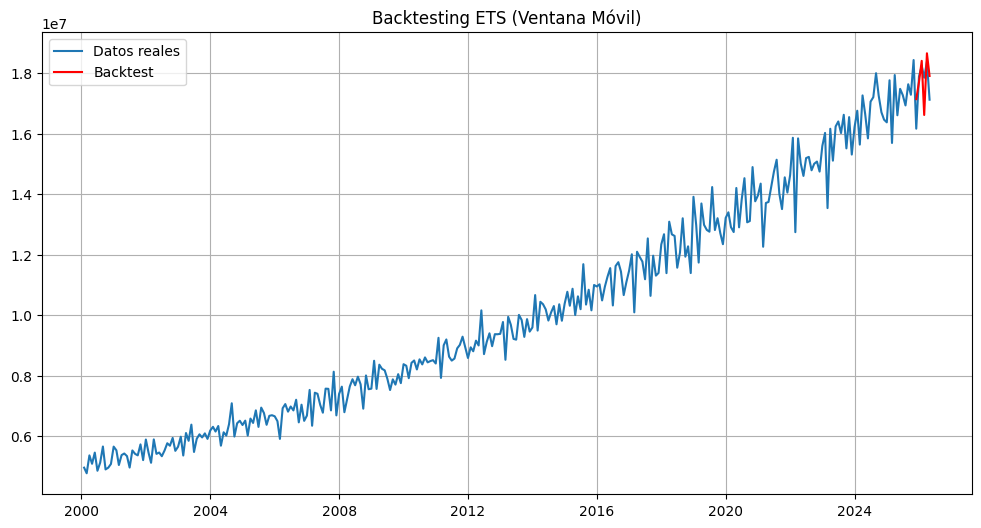

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# 1. Preparar datos
# =========================
data = df_mensual.set_index('FECHA')

y = data['VENTAS'].asfreq('M')

# rellenar posibles huecos
y = y.interpolate()

# evitar problemas multiplicativos
y = y[y > 0]

steps = 1
n_backtesting = 6

# tipo de backtesting
tipo_backtesting = "Ventana Movil"

# combinaciones de hiperparámetros
param_grid = list(product(
    ["add", "mul"],
    ["add", "mul", None],
    ["add", "mul", None]
))

# =========================
# 2. Backtesting (ventana móvil)
# =========================
def backtesting_forecaster(
    y,
    initial_train_size,
    steps,
    error,
    trend,
    seasonal
):

    predictions = []
    true_values = []

    for i in range(initial_train_size, len(y) - steps + 1, steps):

        # =========================
        # VENTANA MÓVIL
        # =========================
        train_y = y[i - initial_train_size:i]

        test_y = y[i:i+steps]

        try:

            model = ETSModel(
                endog=train_y,
                error=error,
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=12
            )

            fit = model.fit(disp=False)

            pred = fit.forecast(steps)

            predictions.extend(pred)
            true_values.extend(test_y)

        except:
            return None, None, None, None

    # validar resultados
    if len(predictions) == 0:
        return None, None, None, None

    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)

    return rmse, mae, r2, predictions

# =========================
# 3. Búsqueda hiperparámetros
# =========================
results = []

best_rmse = float("inf")
best_r2 = -float("inf")

best_params = None
best_predictions = None

for error, trend, seasonal in param_grid:

    print(
        f"Probando: "
        f"error={error}, "
        f"trend={trend}, "
        f"seasonal={seasonal}"
    )

    rmse, mae, r2, preds = backtesting_forecaster(
        y=y,
        initial_train_size=len(y) - n_backtesting,
        steps=steps,
        error=error,
        trend=trend,
        seasonal=seasonal
    )

    if rmse is None:
        continue

    # nombre del modelo
    model_name = (
        f"ETS("
        f"Error={error}, "
        f"Trend={trend}, "
        f"Seasonal={seasonal}"
        f")"
    )

    # guardar resultados
    results.append({
        "Modelo": model_name,
        "Optimizacion": "Grid Search",
        "Tipo_Backtesting": tipo_backtesting,
        "Error": error,
        "Trend": trend,
        "Seasonal": seasonal,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    # priorizar mejor R2
    if r2 > best_r2:

        best_r2 = r2
        best_rmse = rmse

        best_params = (
            error,
            trend,
            seasonal
        )

        best_predictions = preds

# =========================
# 4. Resultados
# =========================
results_df = pd.DataFrame(results)

# ordenar por mejor R2
results_df = results_df.sort_values(
    by=["R2", "RMSE"],
    ascending=[False, True]
)

print("\n============================")
print("MEJORES HIPERPARÁMETROS")
print("============================")

print(
    f"error={best_params[0]}, "
    f"trend={best_params[1]}, "
    f"seasonal={best_params[2]}"
)

print(f"\nRMSE : {best_rmse:.4f}")
print(f"R2   : {best_r2:.4f}")

# =========================
# 5. Guardar o anexar CSV
# =========================
best_result_df = results_df.head(1)

csv_file = "mejor_modelo_ets.csv"

try:

    existing_df = pd.read_csv(csv_file)

    updated_df = pd.concat(
        [existing_df, best_result_df],
        ignore_index=True
    )

    # ordenar por mejor R2
    updated_df = updated_df.sort_values(
        by=["R2", "RMSE"],
        ascending=[False, True]
    )

    updated_df.to_csv(
        csv_file,
        index=False
    )

except:

    best_result_df.to_csv(
        csv_file,
        index=False
    )

print("\nCSV ACTUALIZADO:")
print(csv_file)

# =========================
# 6. Gráfico
# =========================
plt.figure(figsize=(12,6))

plt.plot(
    y,
    label='Datos reales'
)

pred_index = y.index[-len(best_predictions):]

plt.plot(
    pred_index,
    best_predictions,
    color='red',
    label='Backtest'
)

plt.legend()
plt.grid()

plt.title("Backtesting ETS (Ventana Móvil)")

plt.show()

Ahora aplicando optimziación Bayesiana

|   iter    |  target   |   error   |   trend   | seasonal  |
-------------------------------------------------------------
Probando: add, None, mul → RMSE=894079.55 | R2=-0.3924
| 1         | -0.392368 | 0.3745401 | 1.9014286 | 1.4639878 |
Probando: mul, add, add → RMSE=764720.47 | R2=-0.0186
| 2         | -0.018608 | 0.5986584 | 0.3120372 | 0.3119890 |
Probando: add, None, mul → RMSE=894079.55 | R2=-0.3924
| 3         | -0.392368 | 0.0580836 | 1.7323522 | 1.2022300 |
Probando: mul, add, None → RMSE=851008.77 | R2=-0.2614
| 4         | -0.261449 | 0.7080725 | 0.0411689 | 1.9398197 |
Probando: mul, add, add → RMSE=764720.47 | R2=-0.0186
| 5         | -0.018608 | 0.8324426 | 0.4246782 | 0.3636499 |
Probando: mul, add, add → RMSE=764720.47 | R2=-0.0186
| 6         | -0.018608 | 1.0       | 0.0       | 0.0       |
Probando: mul, mul, add → RMSE=732912.92 | R2=0.0644
| 7         | 0.0643645 | 1.0       | 1.3944228 | 0.0       |
Probando: mul, None, add → RMSE=837530.49 | R2=-0.2218
| 8    

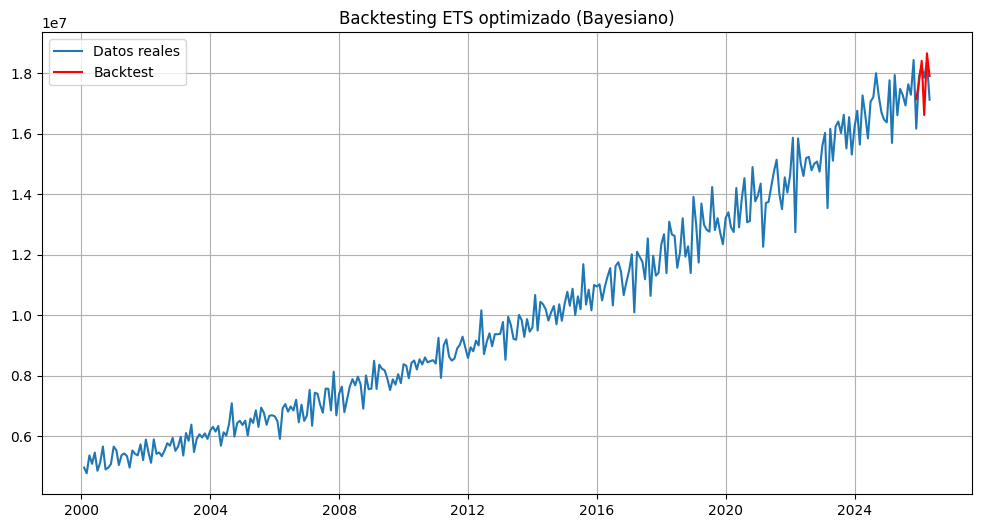

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from bayes_opt import BayesianOptimization

# =========================
# 1. Preparar datos
# =========================
data = df_mensual.set_index('FECHA')

y = data['VENTAS'].asfreq('M').interpolate()

# evitar problemas multiplicativos
y = y[y > 0]

steps = 1
n_backtesting = 6

# tipo backtesting
tipo_backtesting = "Ventana Movil"

# =========================
# 2. Backtesting robusto
# =========================
def backtesting_forecaster(
    y,
    initial_train_size,
    steps,
    error,
    trend,
    seasonal
):

    predictions = []
    true_values = []

    for i in range(initial_train_size, len(y) - steps + 1, steps):

        # =========================
        # VENTANA MÓVIL
        # =========================
        train_y = y[i - initial_train_size:i]

        test_y = y[i:i+steps]

        try:

            model = ETSModel(
                endog=train_y,
                error=error,
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=12
            )

            fit = model.fit(disp=False)

            pred = fit.forecast(steps)

            predictions.extend(pred)
            true_values.extend(test_y)

        except:
            return None, None, None, None, None

    # validar resultados
    if len(predictions) == 0:
        return None, None, None, None, None

    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)

    return rmse, mae, r2, predictions, true_values

# =========================
# 3. Función objetivo
# =========================
def objective_function(error, trend, seasonal):

    error = int(round(error))
    trend = int(round(trend))
    seasonal = int(round(seasonal))

    error_options = ['add', 'mul']
    trend_options = ['add', 'mul', None]
    seasonal_options = ['add', 'mul', None]

    error_param = error_options[error]
    trend_param = trend_options[trend]
    seasonal_param = seasonal_options[seasonal]

    rmse, mae, r2, _, _ = backtesting_forecaster(
        y=y,
        initial_train_size=len(y) - n_backtesting,
        steps=steps,
        error=error_param,
        trend=trend_param,
        seasonal=seasonal_param
    )

    # penalizar combinaciones inválidas
    if rmse is None or np.isnan(rmse):
        return -1e10

    print(
        f"Probando: "
        f"{error_param}, "
        f"{trend_param}, "
        f"{seasonal_param} "
        f"→ RMSE={rmse:.2f} | R2={r2:.4f}"
    )

    # maximizar R2
    return r2

# =========================
# 4. Optimización bayesiana
# =========================
pbounds = {
    'error': (0, 1),
    'trend': (0, 2),
    'seasonal': (0, 2)
}

optimizer = BayesianOptimization(
    f=objective_function,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=25
)

# =========================
# 5. Mejores parámetros
# =========================
best_params = optimizer.max['params']

best_error = ['add', 'mul'][round(best_params['error'])]
best_trend = ['add', 'mul', None][round(best_params['trend'])]
best_seasonal = ['add', 'mul', None][round(best_params['seasonal'])]

print("\n============================")
print("MEJORES HIPERPARÁMETROS")
print("============================")

print(best_error, best_trend, best_seasonal)

# =========================
# 6. Backtesting final
# =========================
best_rmse, best_mae, best_r2, best_predictions, valores_reales = backtesting_forecaster(
    y=y,
    initial_train_size=len(y) - n_backtesting,
    steps=steps,
    error=best_error,
    trend=best_trend,
    seasonal=best_seasonal
)

print(f"\nRMSE : {best_rmse:.4f}")
print(f"MAE  : {best_mae:.4f}")
print(f"R2   : {best_r2:.4f}")

# =========================
# 7. Crear dataframe resultado
# =========================
model_name = (
    f"ETS_BAYESIAN("
    f"Error={best_error}, "
    f"Trend={best_trend}, "
    f"Seasonal={best_seasonal}"
    f")"
)

best_result_df = pd.DataFrame([{
    "Modelo": model_name,
    "Optimizacion": "Bayesiana",
    "Tipo_Backtesting": tipo_backtesting,
    "Error": best_error,
    "Trend": best_trend,
    "Seasonal": best_seasonal,
    "RMSE": best_rmse,
    "MAE": best_mae,
    "R2": best_r2
}])

# =========================
# 8. Guardar o anexar CSV
# =========================
csv_file = "mejor_modelo_ets.csv"

try:

    existing_df = pd.read_csv(csv_file)

    updated_df = pd.concat(
        [existing_df, best_result_df],
        ignore_index=True
    )

    # ordenar por mejor R2
    updated_df = updated_df.sort_values(
        by=["R2", "RMSE"],
        ascending=[False, True]
    )

    updated_df.to_csv(
        csv_file,
        index=False
    )

except:

    best_result_df.to_csv(
        csv_file,
        index=False
    )

print("\nCSV ACTUALIZADO:")
print(csv_file)

# =========================
# 9. Gráfico
# =========================
plt.figure(figsize=(12,6))

plt.plot(
    y,
    label='Datos reales'
)

pred_index = y.index[-len(best_predictions):]

plt.plot(
    pred_index,
    best_predictions,
    color='red',
    label='Backtest'
)

plt.legend()
plt.grid()

plt.title("Backtesting ETS optimizado (Bayesiano)")

plt.show()

## Resumiento todo a una función

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.exponential_smoothing.ets import ETSModel

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from bayes_opt import BayesianOptimization

# =========================
# 1. Backtesting robusto
# =========================
def backtesting_forecaster(
    y,
    initial_train_size,
    steps,
    error,
    trend,
    seasonal,
    ventana="movil"
):

    predictions = []
    true_values = []

    for i in range(initial_train_size, len(y) - steps + 1, steps):

        # =========================
        # TIPO DE VENTANA
        # =========================
        if ventana == "movil":

            train_y = y[i - initial_train_size:i]

        else:

            train_y = y[:i]

        test_y = y[i:i + steps]

        try:

            model = ETSModel(
                endog=train_y,
                error=error,
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=12
            )

            fit = model.fit(disp=False)

            pred = fit.forecast(steps)

            predictions.extend(pred)
            true_values.extend(test_y)

        except:
            return None, None, None, None, None

    # validar predicciones
    if len(predictions) == 0:
        return None, None, None, None, None

    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)

    return rmse, mae, r2, predictions, true_values


# =========================
# 2. ETL
# =========================
def ETL(serie, protocolo="movil"):

    if protocolo not in ["movil", "recursiva"]:
        raise ValueError("Protocolo debe ser 'movil' o 'recursiva'")

    # asegurar serie temporal correcta
    y = serie.asfreq('M').interpolate()

    # evitar problemas multiplicativos
    y = y[y > 0]

    steps = 1
    n_backtesting = 6

    # =========================
    # 3. Función objetivo
    # =========================
    def objective_function(error, trend, seasonal):

        error = int(round(error))
        trend = int(round(trend))
        seasonal = int(round(seasonal))

        error_options = ['add', 'mul']
        trend_options = ['add', 'mul', None]
        seasonal_options = ['add', 'mul', None]

        error_param = error_options[error]
        trend_param = trend_options[trend]
        seasonal_param = seasonal_options[seasonal]

        rmse, mae, r2, _, _ = backtesting_forecaster(
            y=y,
            initial_train_size=len(y) - n_backtesting,
            steps=steps,
            error=error_param,
            trend=trend_param,
            seasonal=seasonal_param,
            ventana=protocolo
        )

        # penalización fuerte
        if rmse is None or np.isnan(rmse):
            return -1e10

        print(
            f"Probando: "
            f"{error_param}, "
            f"{trend_param}, "
            f"{seasonal_param} "
            f"→ RMSE={rmse:.2f} | R2={r2:.4f}"
        )

        # maximizar R2
        return r2

    # =========================
    # 4. Optimización
    # =========================
    optimizer = BayesianOptimization(
        f=objective_function,
        pbounds={
            'error': (0, 1),
            'trend': (0, 2),
            'seasonal': (0, 2)
        },
        random_state=42,
        verbose=2
    )

    optimizer.maximize(
        init_points=5,
        n_iter=25
    )

    # =========================
    # 5. Mejores parámetros
    # =========================
    best_params = optimizer.max['params']

    best_error = ['add', 'mul'][round(best_params['error'])]
    best_trend = ['add', 'mul', None][round(best_params['trend'])]
    best_seasonal = ['add', 'mul', None][round(best_params['seasonal'])]

    print("\n============================")
    print("MEJORES HIPERPARÁMETROS")
    print("============================")

    print(best_error, best_trend, best_seasonal)

    # =========================
    # 6. Backtesting final
    # =========================
    best_rmse, best_mae, best_r2, best_predictions, _ = backtesting_forecaster(
        y=y,
        initial_train_size=len(y) - n_backtesting,
        steps=steps,
        error=best_error,
        trend=best_trend,
        seasonal=best_seasonal,
        ventana=protocolo
    )

    print(f"\nRMSE : {best_rmse:.4f}")
    print(f"MAE  : {best_mae:.4f}")
    print(f"R2   : {best_r2:.4f}")

    # =========================
    # 7. Guardar resultados CSV
    # =========================
    tipo_backtesting = (
        "Ventana Movil"
        if protocolo == "movil"
        else "Ventana Recursiva"
    )

    model_name = (
        f"ETS_BAYESIAN("
        f"Error={best_error}, "
        f"Trend={best_trend}, "
        f"Seasonal={best_seasonal}"
        f")"
    )

    best_result_df = pd.DataFrame([{
        "Modelo": model_name,
        "Optimizacion": "Bayesiana",
        "Tipo_Backtesting": tipo_backtesting,
        "Error": best_error,
        "Trend": best_trend,
        "Seasonal": best_seasonal,
        "RMSE": best_rmse,
        "MAE": best_mae,
        "R2": best_r2
    }])

    csv_file = "mejor_modelo_ets.csv"

    try:

        existing_df = pd.read_csv(csv_file)

        updated_df = pd.concat(
            [existing_df, best_result_df],
            ignore_index=True
        )

        # ordenar por mejor R2
        updated_df = updated_df.sort_values(
            by=["R2", "RMSE"],
            ascending=[False, True]
        )

        updated_df.to_csv(
            csv_file,
            index=False
        )

    except:

        best_result_df.to_csv(
            csv_file,
            index=False
        )

    print("\nCSV ACTUALIZADO:")
    print(csv_file)

    # =========================
    # 8. Gráfico
    # =========================
    plt.figure(figsize=(12,6))

    plt.plot(
        y,
        label='Datos reales'
    )

    pred_index = y.index[-len(best_predictions):]

    plt.plot(
        pred_index,
        best_predictions,
        color='red',
        label='Backtest'
    )

    plt.legend()
    plt.grid()

    plt.title(f"ETS optimizado ({protocolo})")

    plt.show()

    return (
        best_error,
        best_trend,
        best_seasonal,
        best_rmse,
        best_mae,
        best_r2
    )

|   iter    |  target   |   error   |   trend   | seasonal  |
-------------------------------------------------------------
Probando: add, None, mul → RMSE=894079.55 | R2=-0.3924
| 1         | -0.392368 | 0.3745401 | 1.9014286 | 1.4639878 |
Probando: mul, add, add → RMSE=764720.47 | R2=-0.0186
| 2         | -0.018608 | 0.5986584 | 0.3120372 | 0.3119890 |
Probando: add, None, mul → RMSE=894079.55 | R2=-0.3924
| 3         | -0.392368 | 0.0580836 | 1.7323522 | 1.2022300 |
Probando: mul, add, None → RMSE=851008.77 | R2=-0.2614
| 4         | -0.261449 | 0.7080725 | 0.0411689 | 1.9398197 |
Probando: mul, add, add → RMSE=764720.47 | R2=-0.0186
| 5         | -0.018608 | 0.8324426 | 0.4246782 | 0.3636499 |
Probando: mul, add, add → RMSE=764720.47 | R2=-0.0186
| 6         | -0.018608 | 1.0       | 0.0       | 0.0       |
Probando: mul, mul, add → RMSE=732912.92 | R2=0.0644
| 7         | 0.0643645 | 1.0       | 1.3944228 | 0.0       |
Probando: mul, None, add → RMSE=837530.49 | R2=-0.2218
| 8    

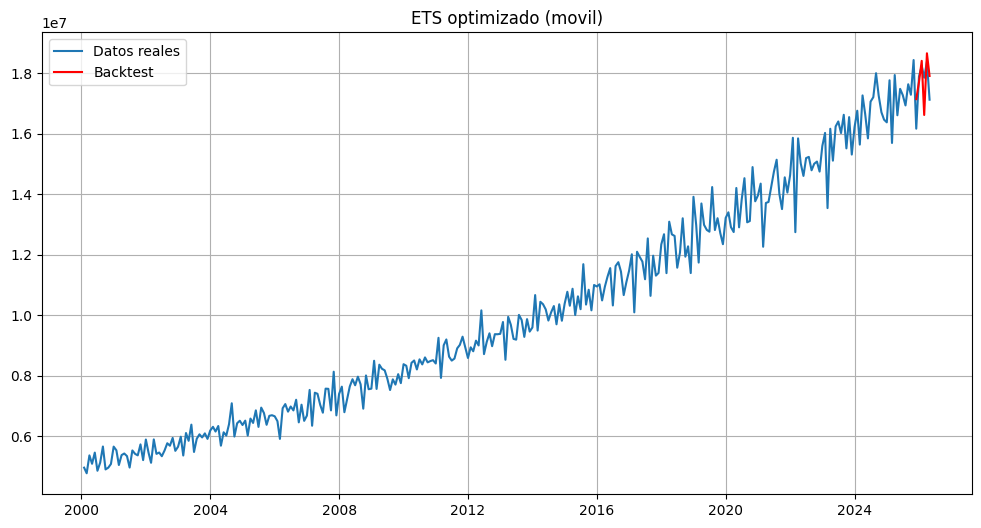

('mul',
 'mul',
 'add',
 np.float64(732912.9192080717),
 603531.185362944,
 0.06436454667835911)

In [ ]:
serie = df_mensual.set_index('FECHA')['VENTAS']

ETL(serie, protocolo="movil")

|   iter    |  target   |   error   |   trend   | seasonal  |
-------------------------------------------------------------
Probando: add, None, mul → RMSE=892651.30 | R2=-0.3879
| 1         | -0.387923 | 0.3745401 | 1.9014286 | 1.4639878 |
Probando: mul, add, add → RMSE=763751.82 | R2=-0.0160
| 2         | -0.016029 | 0.5986584 | 0.3120372 | 0.3119890 |
Probando: add, None, mul → RMSE=892651.30 | R2=-0.3879
| 3         | -0.387923 | 0.0580836 | 1.7323522 | 1.2022300 |
Probando: mul, add, None → RMSE=817177.25 | R2=-0.1631
| 4         | -0.163146 | 0.7080725 | 0.0411689 | 1.9398197 |
Probando: mul, add, add → RMSE=763751.82 | R2=-0.0160
| 5         | -0.016029 | 0.8324426 | 0.4246782 | 0.3636499 |
Probando: mul, add, add → RMSE=763751.82 | R2=-0.0160
| 6         | -0.016029 | 1.0       | 0.0       | 0.0       |
Probando: mul, mul, add → RMSE=720362.52 | R2=0.0961
| 7         | 0.0961338 | 1.0       | 1.3514785 | 0.0       |
Probando: mul, None, add → RMSE=803748.11 | R2=-0.1252
| 8    

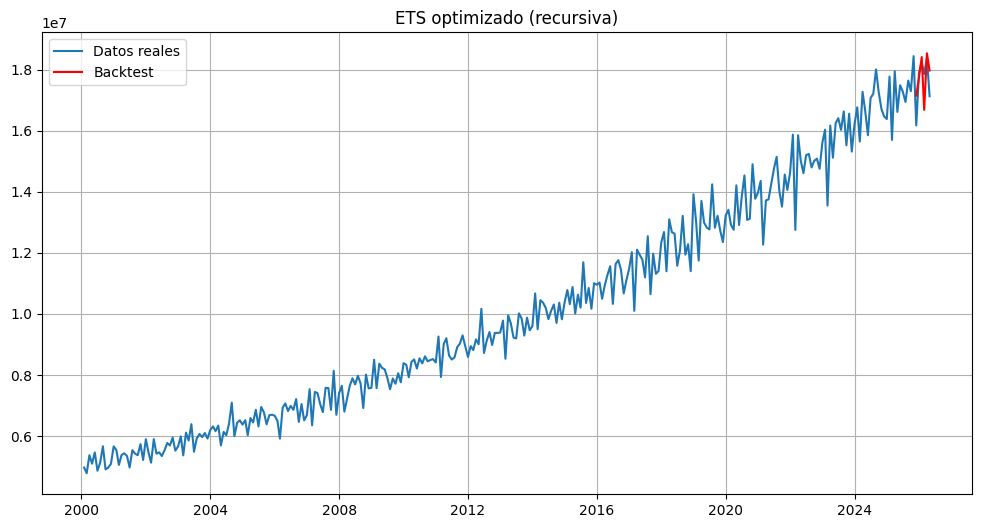

('mul',
 'mul',
 'add',
 np.float64(720362.5195848955),
 576025.069361899,
 0.09613382898752787)

In [ ]:
serie = df_mensual.set_index('FECHA')['VENTAS']

ETL(serie, protocolo="recursiva")

## Ahora tenemos la fucnion completa para parametrizar los steps y los meses test

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.exponential_smoothing.ets import ETSModel

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from bayes_opt import BayesianOptimization

# =========================
# 1. Backtesting robusto
# =========================
def backtesting_forecaster(
    y,
    initial_train_size,
    steps,
    error,
    trend,
    seasonal,
    ventana="movil"
):

    predictions = []
    true_values = []

    for i in range(initial_train_size, len(y) - steps + 1, steps):

        # =========================
        # TIPO DE VENTANA
        # =========================
        if ventana == "movil":

            train_y = y[i - initial_train_size:i]

        else:

            train_y = y[:i]

        test_y = y[i:i + steps]

        try:

            model = ETSModel(
                endog=train_y,
                error=error,
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=12
            )

            fit = model.fit(disp=False)

            pred = fit.forecast(steps)

            predictions.extend(pred)
            true_values.extend(test_y)

        except:
            return None, None, None, None, None

    # validar resultados
    if len(predictions) == 0:
        return None, None, None, None, None

    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)

    return rmse, mae, r2, predictions, true_values


# =========================
# 2. ETL ajustado a tu serie
# =========================
def ETL(
    serie,
    protocolo="movil",
    steps=1,
    n_backtesting=6
):

    if protocolo not in ["movil", "recursiva"]:
        raise ValueError("Protocolo debe ser 'movil' o 'recursiva'")

    # asegurar serie temporal correcta
    y = serie.asfreq('M').interpolate()

    # evitar problemas multiplicativos
    y = y[y > 0]

    # =========================
    # 3. Función objetivo
    # =========================
    def objective_function(error, trend, seasonal):

        error = int(round(error))
        trend = int(round(trend))
        seasonal = int(round(seasonal))

        error_options = ['add', 'mul']
        trend_options = ['add', 'mul', None]
        seasonal_options = ['add', 'mul', None]

        error_param = error_options[error]
        trend_param = trend_options[trend]
        seasonal_param = seasonal_options[seasonal]

        rmse, mae, r2, _, _ = backtesting_forecaster(
            y=y,
            initial_train_size=len(y) - n_backtesting,
            steps=steps,
            error=error_param,
            trend=trend_param,
            seasonal=seasonal_param,
            ventana=protocolo
        )

        # penalización
        if rmse is None or np.isnan(rmse):
            return -1e10

        print(
            f"Probando: "
            f"{error_param}, "
            f"{trend_param}, "
            f"{seasonal_param} "
            f"→ RMSE={rmse:.2f} | R2={r2:.4f}"
        )

        # maximizar R2
        return r2

    # =========================
    # 4. Optimización bayesiana
    # =========================
    optimizer = BayesianOptimization(
        f=objective_function,
        pbounds={
            'error': (0, 1),
            'trend': (0, 2),
            'seasonal': (0, 2)
        },
        random_state=42,
        verbose=2
    )

    optimizer.maximize(
        init_points=5,
        n_iter=25
    )

    # =========================
    # 5. Mejores parámetros
    # =========================
    best_params = optimizer.max['params']

    best_error = ['add', 'mul'][round(best_params['error'])]
    best_trend = ['add', 'mul', None][round(best_params['trend'])]
    best_seasonal = ['add', 'mul', None][round(best_params['seasonal'])]

    print("\n============================")
    print("MEJORES HIPERPARÁMETROS")
    print("============================")

    print(best_error, best_trend, best_seasonal)

    # =========================
    # 6. Backtesting final
    # =========================
    best_rmse, best_mae, best_r2, best_predictions, _ = backtesting_forecaster(
        y=y,
        initial_train_size=len(y) - n_backtesting,
        steps=steps,
        error=best_error,
        trend=best_trend,
        seasonal=best_seasonal,
        ventana=protocolo
    )

    print(f"\nRMSE : {best_rmse:.4f}")
    print(f"MAE  : {best_mae:.4f}")
    print(f"R2   : {best_r2:.4f}")

    # =========================
    # 7. Guardar resultados CSV
    # =========================
    tipo_backtesting = (
        "Ventana Movil"
        if protocolo == "movil"
        else "Ventana Recursiva"
    )

    model_name = (
        f"ETS_BAYESIAN("
        f"Error={best_error}, "
        f"Trend={best_trend}, "
        f"Seasonal={best_seasonal}"
        f")"
    )

    best_result_df = pd.DataFrame([{
        "Modelo": model_name,
        "Optimizacion": "Bayesiana",
        "Tipo_Backtesting": tipo_backtesting,
        "Steps": steps,
        "N_Backtesting": n_backtesting,
        "Error": best_error,
        "Trend": best_trend,
        "Seasonal": best_seasonal,
        "RMSE": best_rmse,
        "MAE": best_mae,
        "R2": best_r2
    }])

    csv_file = "mejor_modelo_ets.csv"

    try:

        existing_df = pd.read_csv(csv_file)

        updated_df = pd.concat(
            [existing_df, best_result_df],
            ignore_index=True
        )

        # ordenar por mejor R2
        updated_df = updated_df.sort_values(
            by=["R2", "RMSE"],
            ascending=[False, True]
        )

        updated_df.to_csv(
            csv_file,
            index=False
        )

    except:

        best_result_df.to_csv(
            csv_file,
            index=False
        )

    print("\nCSV ACTUALIZADO:")
    print(csv_file)

    # =========================
    # 8. Gráfico
    # =========================
    plt.figure(figsize=(12,6))

    plt.plot(
        y,
        label='Datos reales'
    )

    pred_index = y.index[-len(best_predictions):]

    plt.plot(
        pred_index,
        best_predictions,
        color='red',
        label='Backtest'
    )

    plt.legend()
    plt.grid()

    plt.title(f"ETS optimizado ({protocolo})")

    plt.show()

    return (
        best_error,
        best_trend,
        best_seasonal,
        best_rmse,
        best_mae,
        best_r2
    )

|   iter    |  target   |   error   |   trend   | seasonal  |
-------------------------------------------------------------
Probando: add, None, mul → RMSE=894079.55 | R2=-0.3924
| 1         | -0.392368 | 0.3745401 | 1.9014286 | 1.4639878 |
Probando: mul, add, add → RMSE=764720.47 | R2=-0.0186
| 2         | -0.018608 | 0.5986584 | 0.3120372 | 0.3119890 |
Probando: add, None, mul → RMSE=894079.55 | R2=-0.3924
| 3         | -0.392368 | 0.0580836 | 1.7323522 | 1.2022300 |
Probando: mul, add, None → RMSE=851008.77 | R2=-0.2614
| 4         | -0.261449 | 0.7080725 | 0.0411689 | 1.9398197 |
Probando: mul, add, add → RMSE=764720.47 | R2=-0.0186
| 5         | -0.018608 | 0.8324426 | 0.4246782 | 0.3636499 |
Probando: mul, add, add → RMSE=764720.47 | R2=-0.0186
| 6         | -0.018608 | 1.0       | 0.0       | 0.0       |
Probando: mul, mul, add → RMSE=732912.92 | R2=0.0644
| 7         | 0.0643645 | 1.0       | 1.3944228 | 0.0       |
Probando: mul, None, add → RMSE=837530.49 | R2=-0.2218
| 8    

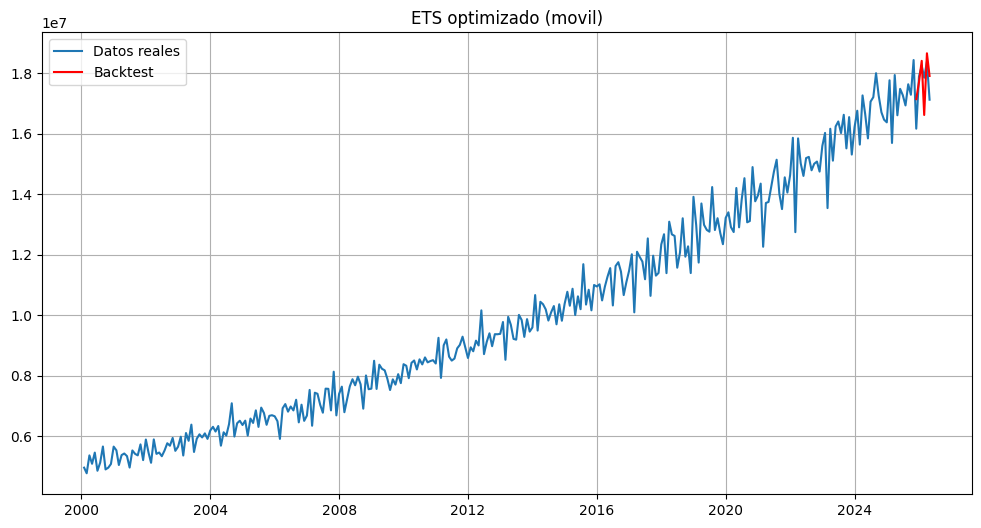

('mul',
 'mul',
 'add',
 np.float64(732912.9192080717),
 603531.185362944,
 0.06436454667835911)

In [ ]:
serie = df_mensual.set_index('FECHA')['VENTAS']

ETL(serie, protocolo="movil", steps=1, n_backtesting=6)

# Ahora con regresion lineal y polinomial usando dumificacion

---



In [ ]:
data

,VENTAS
FECHA,
2000-01-31,4966041.0
2000-02-29,4780084.0
2000-03-31,5371961.0
2000-04-30,5093745.0
2000-05-31,5464223.0
...,...
2025-12-31,17895030.0
2026-01-31,18242407.0
2026-02-28,17855165.0


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# 1. Preparar datos
# =========================
y = data["VENTAS"]

x = np.linspace(
    1,
    data.shape[0],
    data.shape[0]
)

X = sm.add_constant(x)

# =========================
# 2. Modelo OLS
# =========================
lin = sm.OLS(y, X)

lin_t = lin.fit()

# =========================
# 3. Predicciones
# =========================
predicciones = lin_t.predict(X)

# =========================
# 4. Métricas
# =========================
rmse = np.sqrt(
    mean_squared_error(y, predicciones)
)

mae = mean_absolute_error(
    y,
    predicciones
)

r2 = r2_score(
    y,
    predicciones
)

# =========================
# 5. Resultados
# =========================
print(lin_t.summary())

print("\n============================")
print("MÉTRICAS DEL MODELO")
print("============================")

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2   : {r2:.4f}")

# =========================
# 6. Guardar resultados CSV
# =========================
model_name = "OLS_Linear_Regression"

best_result_df = pd.DataFrame([{
    "Modelo": model_name,
    "Optimizacion": "Ninguna",
    "Tipo_Backtesting": "Sin Backtesting",
    "Steps": None,
    "N_Backtesting": None,
    "Error": None,
    "Trend": None,
    "Seasonal": None,
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2
}])

csv_file = "mejor_modelo_ets.csv"

try:

    existing_df = pd.read_csv(csv_file)

    updated_df = pd.concat(
        [existing_df, best_result_df],
        ignore_index=True
    )

    # ordenar por mejor R2
    updated_df = updated_df.sort_values(
        by=["R2", "RMSE"],
        ascending=[False, True]
    )

    updated_df.to_csv(
        csv_file,
        index=False
    )

except:

    best_result_df.to_csv(
        csv_file,
        index=False
    )

print("\nCSV ACTUALIZADO:")
print(csv_file)

                            OLS Regression Results                            
Dep. Variable:                 VENTAS   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     6698.
Date:                Sat, 30 May 2026   Prob (F-statistic):          7.66e-214
Time:                        14:57:51   Log-Likelihood:                -4741.6
No. Observations:                 316   AIC:                             9487.
Df Residuals:                     314   BIC:                             9495.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.793e+06   8.99e+04     42.173      0.0

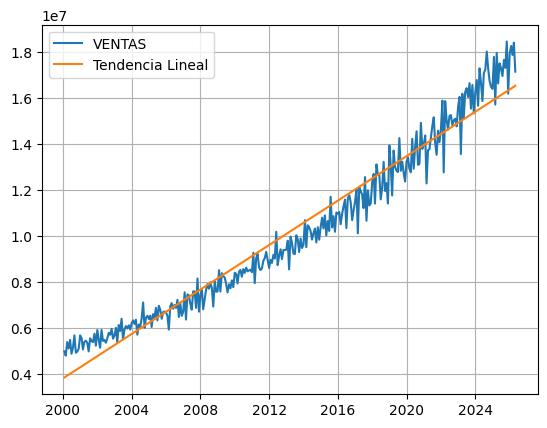

In [ ]:
plt.plot(y,label="VENTAS")
plt.plot(lin_t.fittedvalues,label="Tendencia Lineal")
plt.legend()
plt.grid()
plt.show()

    Point_forecast      lower_95      upper_95
0     1.655319e+07  1.497402e+07  1.813235e+07
1     1.659344e+07  1.501418e+07  1.817270e+07
2     1.663369e+07  1.505434e+07  1.821305e+07
3     1.667394e+07  1.509449e+07  1.825339e+07
4     1.671420e+07  1.513465e+07  1.829374e+07
5     1.675445e+07  1.517481e+07  1.833409e+07
6     1.679470e+07  1.521496e+07  1.837444e+07
7     1.683495e+07  1.525512e+07  1.841479e+07
8     1.687521e+07  1.529527e+07  1.845514e+07
9     1.691546e+07  1.533542e+07  1.849549e+07
10    1.695571e+07  1.537558e+07  1.853584e+07
11    1.699596e+07  1.541573e+07  1.857620e+07

MÉTRICAS DEL MODELO
RMSE : 795022.2046
MAE  : 643961.4120
R2   : 0.9552

CSV ACTUALIZADO:
mejor_modelo_ets.csv


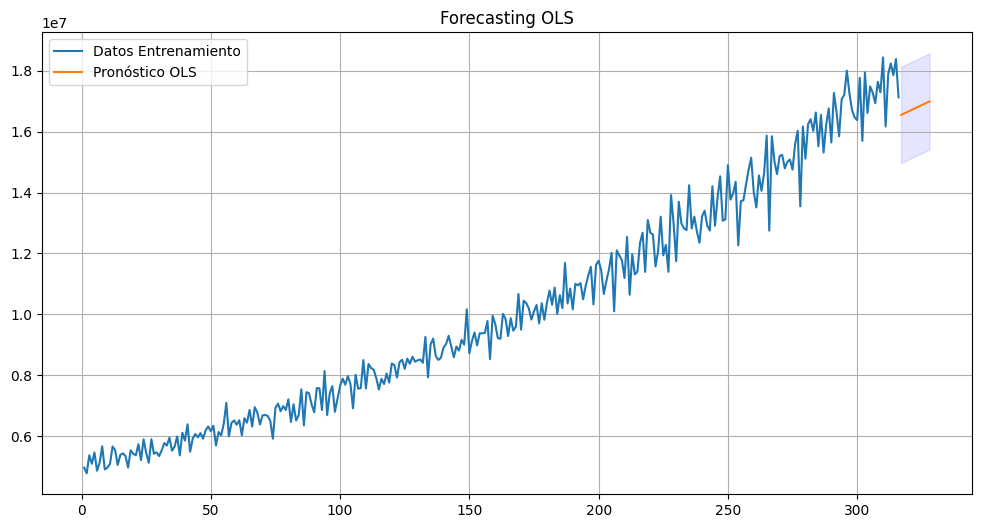

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# 1. Horizonte pronóstico
# =========================
h = 12

# =========================
# 2. Generar futuro
# =========================
x_for = np.linspace(
    (data.shape[0] + 1),
    (data.shape[0] + h),
    h
)

X_for = sm.add_constant(x_for)

# =========================
# 3. Predicción
# =========================
dt = lin_t.get_prediction(X_for).summary_frame(alpha=0.05)

y_prd = dt['mean']

yprd_ci_lower = dt['obs_ci_lower']

yprd_ci_upper = dt['obs_ci_upper']

# =========================
# 4. DataFrame predicciones
# =========================
preds = pd.DataFrame(
    np.column_stack([
        y_prd,
        yprd_ci_lower,
        yprd_ci_upper
    ])
)

preds.columns = [
    'Point_forecast',
    'lower_95',
    'upper_95'
]

print(preds)

# =========================
# 5. Métricas entrenamiento
# =========================
pred_train = lin_t.predict(X)

rmse = np.sqrt(
    mean_squared_error(y, pred_train)
)

mae = mean_absolute_error(
    y,
    pred_train
)

r2 = r2_score(
    y,
    pred_train
)

print("\n============================")
print("MÉTRICAS DEL MODELO")
print("============================")

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2   : {r2:.4f}")

# =========================
# 6. Guardar resultados CSV
# =========================
model_name = "OLS_Forecasting"

best_result_df = pd.DataFrame([{
    "Modelo": model_name,
    "Optimizacion": "Ninguna",
    "Tipo_Backtesting": "Forecasting Lineal",
    "Steps": h,
    "N_Backtesting": None,
    "Error": None,
    "Trend": "Lineal",
    "Seasonal": None,
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2
}])

csv_file = "mejor_modelo_ets.csv"

try:

    existing_df = pd.read_csv(csv_file)

    updated_df = pd.concat(
        [existing_df, best_result_df],
        ignore_index=True
    )

    # ordenar por mejor R2
    updated_df = updated_df.sort_values(
        by=["R2", "RMSE"],
        ascending=[False, True]
    )

    updated_df.to_csv(
        csv_file,
        index=False
    )

except:

    best_result_df.to_csv(
        csv_file,
        index=False
    )

print("\nCSV ACTUALIZADO:")
print(csv_file)

# =========================
# 7. Gráfico
# =========================
fig = plt.figure(figsize=(12, 6))

# datos históricos
plt.plot(
    x,
    y,
    label="Datos Entrenamiento"
)

# forecast
plt.plot(
    x_for,
    preds['Point_forecast'],
    label="Pronóstico OLS"
)

# intervalo confianza
plt.fill_between(
    x_for,
    preds['lower_95'],
    preds['upper_95'],
    color='blue',
    alpha=0.1
)

plt.legend()

plt.grid()

plt.title("Forecasting OLS")

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# 1. Variables
# =========================
y = data["VENTAS"]

# =========================
# 2. Variables polinomiales
# =========================
data["x"] = np.linspace(
    1,
    data.shape[0],
    data.shape[0]
)

x = data["x"]

data["x2"] = x**2
data["x3"] = x**3
data["x4"] = x**4
data["x5"] = x**5
data["x6"] = x**6

# =========================
# 3. Modelo polinomial grado 6
# =========================
X = sm.add_constant(
    data[[
        "x",
        "x2",
        "x3",
        "x4",
        "x5",
        "x6"
    ]]
)

pol = sm.OLS(y, X)

pol_2 = pol.fit()

# =========================
# 4. Predicciones
# =========================
predicciones = pol_2.predict(X)

# =========================
# 5. Métricas
# =========================
rmse = np.sqrt(
    mean_squared_error(y, predicciones)
)

mae = mean_absolute_error(
    y,
    predicciones
)

r2 = r2_score(
    y,
    predicciones
)

# =========================
# 6. Resultados
# =========================
print(pol_2.summary())

print("\n============================")
print("MÉTRICAS DEL MODELO")
print("============================")

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2   : {r2:.4f}")

# =========================
# 7. Guardar resultados CSV
# =========================
model_name = "OLS_Polinomial_Grado_6"

best_result_df = pd.DataFrame([{
    "Modelo": model_name,
    "Optimizacion": "Ninguna",
    "Tipo_Backtesting": "Sin Backtesting",
    "Steps": None,
    "N_Backtesting": None,
    "Error": None,
    "Trend": "Polinomial_Grado_6",
    "Seasonal": None,
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2
}])

csv_file = "mejor_modelo_ets.csv"

try:

    existing_df = pd.read_csv(csv_file)

    updated_df = pd.concat(
        [existing_df, best_result_df],
        ignore_index=True
    )

    # ordenar por mejor R2
    updated_df = updated_df.sort_values(
        by=["R2", "RMSE"],
        ascending=[False, True]
    )

    updated_df.to_csv(
        csv_file,
        index=False
    )

except:

    best_result_df.to_csv(
        csv_file,
        index=False
    )

print("\nCSV ACTUALIZADO:")
print(csv_file)

                            OLS Regression Results                            
Dep. Variable:                 VENTAS   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     1164.
Date:                Sat, 30 May 2026   Prob (F-statistic):          1.84e-198
Time:                        14:57:51   Log-Likelihood:                -4760.9
No. Observations:                 316   AIC:                             9534.
Df Residuals:                     310   BIC:                             9556.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.042e+04   1111.992     27.361      0.0

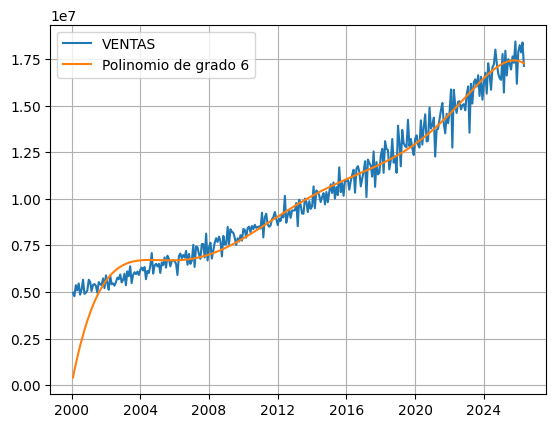

In [ ]:
plt.plot(y,label="VENTAS")
plt.plot(pol_2.fittedvalues,label="Polinomio de grado 6")
plt.legend()
plt.grid()
plt.show()

   Point_forecast      lower_95      upper_95
0    1.721125e+07  1.540061e+07  1.902188e+07
1    1.714937e+07  1.531861e+07  1.898012e+07
2    1.707849e+07  1.522487e+07  1.893212e+07
3    1.699825e+07  1.511877e+07  1.887772e+07
4    1.690824e+07  1.499969e+07  1.881679e+07
5    1.680809e+07  1.486697e+07  1.874920e+07

MÉTRICAS DEL MODELO
RMSE : 845029.0962
MAE  : 567382.6989
R2   : 0.9494

CSV ACTUALIZADO:
mejor_modelo_ets.csv


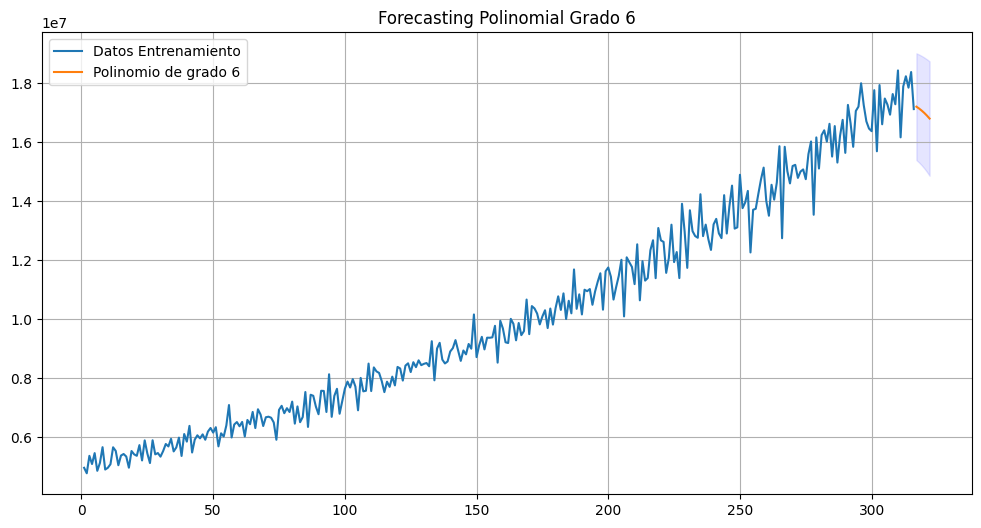

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# 1. Horizonte de predicción
# =========================
h = 6

# =========================
# 2. Generar valores futuros
# =========================
x_for = np.linspace(
    (data.shape[0] + 1),
    (data.shape[0] + h),
    h
)

# =========================
# 3. Variables polinomiales futuras
# =========================
X_for = sm.add_constant(
    np.column_stack([
        x_for,
        x_for**2,
        x_for**3,
        x_for**4,
        x_for**5,
        x_for**6
    ])
)

# =========================
# 4. Predicción
# =========================
dt = pol_2.get_prediction(X_for).summary_frame(alpha=0.05)

# predicción puntual
y_prd = dt['mean']

# intervalos confianza
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']

# =========================
# 5. DataFrame resultados
# =========================
preds = pd.DataFrame(
    np.column_stack([
        y_prd,
        yprd_ci_lower,
        yprd_ci_upper
    ])
)

preds.columns = [
    'Point_forecast',
    'lower_95',
    'upper_95'
]

print(preds)

# =========================
# 6. Métricas entrenamiento
# =========================
pred_train = pol_2.predict(X)

rmse = np.sqrt(
    mean_squared_error(y, pred_train)
)

mae = mean_absolute_error(
    y,
    pred_train
)

r2 = r2_score(
    y,
    pred_train
)

print("\n============================")
print("MÉTRICAS DEL MODELO")
print("============================")

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2   : {r2:.4f}")

# =========================
# 7. Guardar resultados CSV
# =========================
model_name = "OLS_Forecasting_Polinomial_Grado_6"

best_result_df = pd.DataFrame([{
    "Modelo": model_name,
    "Optimizacion": "Ninguna",
    "Tipo_Backtesting": "Forecasting Polinomial",
    "Steps": h,
    "N_Backtesting": None,
    "Error": None,
    "Trend": "Polinomial_Grado_6",
    "Seasonal": None,
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2
}])

csv_file = "mejor_modelo_ets.csv"

try:

    existing_df = pd.read_csv(csv_file)

    updated_df = pd.concat(
        [existing_df, best_result_df],
        ignore_index=True
    )

    # ordenar por mejor R2
    updated_df = updated_df.sort_values(
        by=["R2", "RMSE"],
        ascending=[False, True]
    )

    updated_df.to_csv(
        csv_file,
        index=False
    )

except:

    best_result_df.to_csv(
        csv_file,
        index=False
    )

print("\nCSV ACTUALIZADO:")
print(csv_file)

# =========================
# 8. Gráfico
# =========================
fig = plt.figure(figsize=(12, 6))

# datos históricos
plt.plot(
    data["x"],
    y,
    label="Datos Entrenamiento"
)

# forecast
plt.plot(
    x_for,
    preds['Point_forecast'],
    label="Polinomio de grado 6"
)

# intervalos confianza
plt.fill_between(
    x_for,
    preds['lower_95'],
    preds['upper_95'],
    color='blue',
    alpha=0.1
)

plt.legend()

plt.grid()

plt.title("Forecasting Polinomial Grado 6")

plt.show()


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# 1. Variables estacionales
# =========================
month_dummies = pd.get_dummies(
    data.index.month,
    drop_first=True
).set_index(data.index).astype(int)

# =========================
# 2. Variables modelo
# =========================
y = data["VENTAS"]

X = sm.add_constant(month_dummies)

# =========================
# 3. Modelo OLS estacional
# =========================
sea = sm.OLS(y, X)

season = sea.fit()

# =========================
# 4. Predicciones
# =========================
predicciones = season.predict(X)

# =========================
# 5. Métricas
# =========================
rmse = np.sqrt(
    mean_squared_error(y, predicciones)
)

mae = mean_absolute_error(
    y,
    predicciones
)

r2 = r2_score(
    y,
    predicciones
)

# =========================
# 6. Resultados
# =========================
print(season.summary())

print("\n============================")
print("MÉTRICAS DEL MODELO")
print("============================")

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2   : {r2:.4f}")

# =========================
# 7. Guardar resultados CSV
# =========================
model_name = "OLS_Estacional_Mensual"

best_result_df = pd.DataFrame([{
    "Modelo": model_name,
    "Optimizacion": "Ninguna",
    "Tipo_Backtesting": "Sin Backtesting",
    "Steps": None,
    "N_Backtesting": None,
    "Error": None,
    "Trend": "Estacional_Mensual",
    "Seasonal": "Dummies_Mensuales",
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2
}])

csv_file = "mejor_modelo_ets.csv"

try:

    existing_df = pd.read_csv(csv_file)

    updated_df = pd.concat(
        [existing_df, best_result_df],
        ignore_index=True
    )

    # ordenar por mejor R2
    updated_df = updated_df.sort_values(
        by=["R2", "RMSE"],
        ascending=[False, True]
    )

    updated_df.to_csv(
        csv_file,
        index=False
    )

except:

    best_result_df.to_csv(
        csv_file,
        index=False
    )

print("\nCSV ACTUALIZADO:")
print(csv_file)

                            OLS Regression Results                            
Dep. Variable:                 VENTAS   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.030
Method:                 Least Squares   F-statistic:                    0.1719
Date:                Sat, 30 May 2026   Prob (F-statistic):              0.999
Time:                        14:57:52   Log-Likelihood:                -5231.4
No. Observations:                 316   AIC:                         1.049e+04
Df Residuals:                     304   BIC:                         1.053e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.051e+07   7.35e+05     14.307      0.0

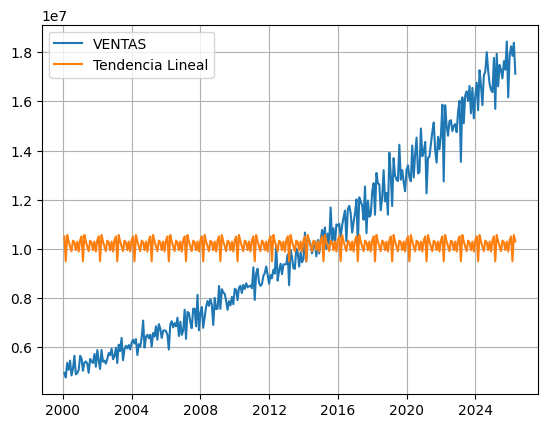

In [ ]:
plt.plot(y,label="VENTAS")
plt.plot(season.fittedvalues,label="Tendencia Lineal")
plt.legend()
plt.grid()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                 VENTAS   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     1305.
Date:                Sat, 30 May 2026   Prob (F-statistic):          8.22e-206
Time:                        14:57:52   Log-Likelihood:                -4743.6
No. Observations:                 316   AIC:                             9499.
Df Residuals:                     310   BIC:                             9522.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.513e+04   6924.199      5.074      0.0

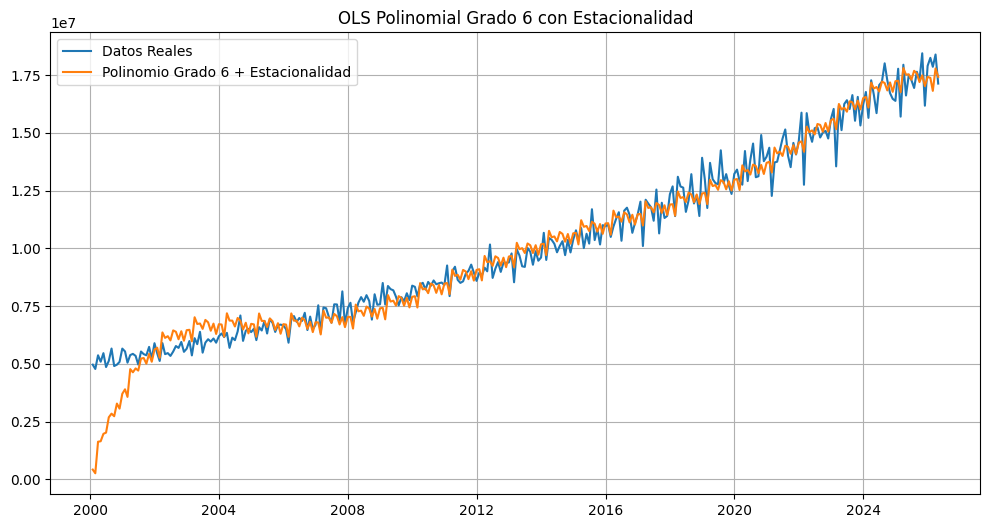

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# 1. Dummies estacionales
# =========================
month_dummies = pd.get_dummies(
    data.index.month,
    drop_first=True
).set_index(data.index).astype(int)

# =========================
# 2. Variable dependiente
# =========================
y = data["VENTAS"]

# =========================
# 3. Variables polinomiales
# =========================
data["x"] = np.linspace(
    1,
    data.shape[0],
    data.shape[0]
)

data["x2"] = data["x"] ** 2
data["x3"] = data["x"] ** 3
data["x4"] = data["x"] ** 4
data["x5"] = data["x"] ** 5
data["x6"] = data["x"] ** 6

# =========================
# 4. Variables explicativas
# =========================
X = pd.concat(
    [
        data[[
            "x",
            "x2",
            "x3",
            "x4",
            "x5",
            "x6"
        ]],
        month_dummies
    ],
    axis=1
)

# intercepto
X = sm.add_constant(X)

# =========================
# 5. Modelo OLS
# =========================
pol_sea = sm.OLS(y, X)

pol_season = pol_sea.fit()

# =========================
# 6. Predicciones
# =========================
predicciones = pol_season.fittedvalues

# =========================
# 7. Métricas
# =========================
rmse = np.sqrt(
    mean_squared_error(y, predicciones)
)

mae = mean_absolute_error(
    y,
    predicciones
)

r2 = r2_score(
    y,
    predicciones
)

# =========================
# 8. Resultados
# =========================
print(pol_season.summary())

print("\n============================")
print("MÉTRICAS DEL MODELO")
print("============================")

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2   : {r2:.4f}")

# =========================
# 9. Guardar resultados CSV
# =========================
model_name = "OLS_Polinomial_Grado_6_Estacional"

best_result_df = pd.DataFrame([{
    "Modelo": model_name,
    "Optimizacion": "Ninguna",
    "Tipo_Backtesting": "Sin Backtesting",
    "Steps": None,
    "N_Backtesting": None,
    "Error": None,
    "Trend": "Polinomial_Grado_6",
    "Seasonal": "Dummies_Mensuales",
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2
}])

csv_file = "mejor_modelo_ets.csv"

try:

    existing_df = pd.read_csv(csv_file)

    updated_df = pd.concat(
        [existing_df, best_result_df],
        ignore_index=True
    )

    # ordenar por mejor R2
    updated_df = updated_df.sort_values(
        by=["R2", "RMSE"],
        ascending=[False, True]
    )

    updated_df.to_csv(
        csv_file,
        index=False
    )

except:

    best_result_df.to_csv(
        csv_file,
        index=False
    )

print("\nCSV ACTUALIZADO:")
print(csv_file)

# =========================
# 10. Gráfico
# =========================
plt.figure(figsize=(12,6))

# datos reales
plt.plot(
    y,
    label="Datos Reales"
)

# valores ajustados
plt.plot(
    predicciones,
    label="Polinomio Grado 6 + Estacionalidad"
)

plt.legend()

plt.grid()

plt.title("OLS Polinomial Grado 6 con Estacionalidad")

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# FUNCIÓN RMSE
# =========================
def rmse(y_true, y_pred):

    return np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

# =========================
# FUNCIÓN PRINCIPAL
# =========================
def evaluar_modelos_rmse(
    data,
    col_producto,
    max_grado=10,
    modo="tabla"
):

    """
    Evalúa modelos polinomiales
    con y sin estacionalidad.

    Parámetros:
    -----------
    data : DataFrame
    col_producto : str
    max_grado : int
    modo : str

    Retorna:
    --------
    DataFrame o imprime mejor modelo
    """

    # =========================
    # VARIABLE DEPENDIENTE
    # =========================
    y = data[col_producto]

    # =========================
    # DUMMIES ESTACIONALES
    # =========================
    month_dummies = pd.get_dummies(
        data.index.month,
        drop_first=True
    ).set_index(data.index).astype(int)

    # =========================
    # RESULTADOS
    # =========================
    resultados = []

    # =========================
    # EVALUAR GRADOS
    # =========================
    for grado in range(1, max_grado + 1):

        # =========================
        # VARIABLE TIEMPO
        # =========================
        data["x"] = np.linspace(
            1,
            data.shape[0],
            data.shape[0]
        )

        # =========================
        # VARIABLES POLINOMIALES
        # =========================
        columnas_poly = ["x"]

        for g in range(2, grado + 1):

            data[f"x{g}"] = data["x"] ** g

            columnas_poly.append(f"x{g}")

        # =========================
        # MATRIZ SIN ESTACIONALIDAD
        # =========================
        X_sin_est = sm.add_constant(
            data[columnas_poly]
        )

        # =========================
        # MATRIZ CON ESTACIONALIDAD
        # =========================
        X_con_est = pd.concat(
            [X_sin_est, month_dummies],
            axis=1
        )

        # =========================
        # MODELO SIN ESTACIONALIDAD
        # =========================
        modelo_sin_est = sm.OLS(
            y,
            X_sin_est
        ).fit()

        pred_sin_est = modelo_sin_est.fittedvalues

        # =========================
        # MODELO CON ESTACIONALIDAD
        # =========================
        modelo_con_est = sm.OLS(
            y,
            X_con_est
        ).fit()

        pred_con_est = modelo_con_est.fittedvalues

        # =========================
        # MÉTRICAS SIN ESTACIONALIDAD
        # =========================
        rmse_sin_est = rmse(
            y,
            pred_sin_est
        )

        mae_sin_est = mean_absolute_error(
            y,
            pred_sin_est
        )

        r2_sin_est = r2_score(
            y,
            pred_sin_est
        )

        # =========================
        # MÉTRICAS CON ESTACIONALIDAD
        # =========================
        rmse_con_est = rmse(
            y,
            pred_con_est
        )

        mae_con_est = mean_absolute_error(
            y,
            pred_con_est
        )

        r2_con_est = r2_score(
            y,
            pred_con_est
        )

        # =========================
        # GUARDAR RESULTADOS
        # =========================
        resultados.append({

            "grado": grado,

            "RMSE_sin_estacionalidad": rmse_sin_est,
            "MAE_sin_estacionalidad": mae_sin_est,
            "R2_sin_estacionalidad": r2_sin_est,

            "RMSE_con_estacionalidad": rmse_con_est,
            "MAE_con_estacionalidad": mae_con_est,
            "R2_con_estacionalidad": r2_con_est

        })

    # =========================
    # DATAFRAME RESULTADOS
    # =========================
    resultados_df = pd.DataFrame(resultados)

    # =========================
    # GUARDAR CSV COMPLETO
    # =========================
    resultados_df.to_csv(
        "comparacion_modelos_polinomiales.csv",
        index=False
    )

    print("\nCSV GUARDADO:")
    print("comparacion_modelos_polinomiales.csv")

    # =========================
    # MODO TABLA
    # =========================
    if modo == "tabla":

        return resultados_df

    # =========================
    # MODO MEJOR MODELO
    # =========================
    elif modo == "mejor":

        # =========================
        # MEJOR SIN ESTACIONALIDAD
        # =========================
        mejor_sin_est = resultados_df.loc[
            resultados_df[
                'RMSE_sin_estacionalidad'
            ].idxmin()
        ]

        # =========================
        # MEJOR CON ESTACIONALIDAD
        # =========================
        mejor_con_est = resultados_df.loc[
            resultados_df[
                'RMSE_con_estacionalidad'
            ].idxmin()
        ]

        print("\n============================")
        print("MEJOR MODELO SIN ESTACIONALIDAD")
        print("============================")

        print(
            f"Polinomio grado "
            f"{int(mejor_sin_est['grado'])}"
        )

        print(
            f"RMSE : "
            f"{mejor_sin_est['RMSE_sin_estacionalidad']:.4f}"
        )

        print(
            f"MAE  : "
            f"{mejor_sin_est['MAE_sin_estacionalidad']:.4f}"
        )

        print(
            f"R2   : "
            f"{mejor_sin_est['R2_sin_estacionalidad']:.4f}"
        )

        print("\n============================")
        print("MEJOR MODELO CON ESTACIONALIDAD")
        print("============================")

        print(
            f"Polinomio grado "
            f"{int(mejor_con_est['grado'])}"
        )

        print(
            f"RMSE : "
            f"{mejor_con_est['RMSE_con_estacionalidad']:.4f}"
        )

        print(
            f"MAE  : "
            f"{mejor_con_est['MAE_con_estacionalidad']:.4f}"
        )

        print(
            f"R2   : "
            f"{mejor_con_est['R2_con_estacionalidad']:.4f}"
        )

        # =========================
        # GUARDAR MEJORES MODELOS
        # =========================
        mejores_modelos = pd.DataFrame([

            {
                "Modelo": f"Polinomio_Grado_{int(mejor_sin_est['grado'])}",
                "Optimizacion": "Ninguna",
                "Tipo_Backtesting": "Sin Backtesting",
                "Steps": None,
                "N_Backtesting": None,
                "Error": None,
                "Trend": f"Polinomio_Grado_{int(mejor_sin_est['grado'])}",
                "Seasonal": "No",
                "RMSE": mejor_sin_est['RMSE_sin_estacionalidad'],
                "MAE": mejor_sin_est['MAE_sin_estacionalidad'],
                "R2": mejor_sin_est['R2_sin_estacionalidad']
            },

            {
                "Modelo": f"Polinomio_Grado_{int(mejor_con_est['grado'])}_Estacional",
                "Optimizacion": "Ninguna",
                "Tipo_Backtesting": "Sin Backtesting",
                "Steps": None,
                "N_Backtesting": None,
                "Error": None,
                "Trend": f"Polinomio_Grado_{int(mejor_con_est['grado'])}",
                "Seasonal": "Dummies_Mensuales",
                "RMSE": mejor_con_est['RMSE_con_estacionalidad'],
                "MAE": mejor_con_est['MAE_con_estacionalidad'],
                "R2": mejor_con_est['R2_con_estacionalidad']
            }

        ])

        csv_file = "mejor_modelo_ets.csv"

        try:

            existing_df = pd.read_csv(csv_file)

            updated_df = pd.concat(
                [existing_df, mejores_modelos],
                ignore_index=True
            )

            updated_df = updated_df.sort_values(
                by=["R2", "RMSE"],
                ascending=[False, True]
            )

            updated_df.to_csv(
                csv_file,
                index=False
            )

        except:

            mejores_modelos.to_csv(
                csv_file,
                index=False
            )

        print("\nCSV ACTUALIZADO:")
        print(csv_file)

    else:

        raise ValueError(
            "Modo no reconocido. Usa 'tabla' o 'mejor'."
        )


# =========================
# EJEMPLOS DE USO
# =========================

# TABLA COMPLETA
# tabla_resultados = evaluar_modelos_rmse(
#     data,
#     "VENTAS",
#     max_grado=10,
#     modo="tabla"
# )

# MEJOR MODELO
# evaluar_modelos_rmse(
#     data,
#     "VENTAS",
#     max_grado=10,
#     modo="mejor"
# )


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# FUNCIÓN RMSE
# =========================
def rmse(y_true, y_pred):

    return np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

# =========================
# FUNCIÓN PRINCIPAL
# =========================
def evaluar_modelos_rmse(
    data,
    col_producto,
    max_grado=10,
    modo="mejor",
    meses_test=6
):

    """
    Evaluar modelos polinomiales
    con y sin estacionalidad.

    Parámetros:
    -----------
    data : DataFrame
    col_producto : str
    max_grado : int
    modo : str
    meses_test : int
    """

    # =========================
    # TRAIN / TEST
    # =========================
    train_data = data.iloc[:-meses_test].copy()

    test_data = data.iloc[-meses_test:].copy()

    # =========================
    # VARIABLES DEPENDIENTES
    # =========================
    y_train = train_data[col_producto]

    y_test = test_data[col_producto]

    # =========================
    # DUMMIES ESTACIONALES
    # =========================
    month_dummies_train = pd.get_dummies(
        train_data.index.month,
        drop_first=True
    ).set_index(train_data.index).astype(int)

    month_dummies_test = pd.get_dummies(
        test_data.index.month,
        drop_first=True
    ).set_index(test_data.index).astype(int)

    # alinear columnas
    month_dummies_test = month_dummies_test.reindex(
        columns=month_dummies_train.columns,
        fill_value=0
    )

    # =========================
    # RESULTADOS
    # =========================
    resultados = []

    # =========================
    # LOOP MODELOS
    # =========================
    for grado in range(1, max_grado + 1):

        # =========================
        # VARIABLES TIEMPO
        # =========================
        train_data.loc[:, "x"] = np.arange(
            1,
            len(train_data) + 1
        )

        test_data.loc[:, "x"] = np.arange(
            len(train_data) + 1,
            len(train_data) + len(test_data) + 1
        )

        # =========================
        # VARIABLES POLINOMIALES
        # =========================
        columnas_poly = ["x"]

        for g in range(2, grado + 1):

            train_data.loc[:, f"x{g}"] = (
                train_data["x"] ** g
            )

            test_data.loc[:, f"x{g}"] = (
                test_data["x"] ** g
            )

            columnas_poly.append(f"x{g}")

        # =========================
        # MATRICES SIN ESTACIONALIDAD
        # =========================
        X_train_sin_est = sm.add_constant(
            train_data[columnas_poly]
        )

        X_test_sin_est = sm.add_constant(
            test_data[columnas_poly]
        )

        # =========================
        # MATRICES CON ESTACIONALIDAD
        # =========================
        X_train_con_est = pd.concat(
            [X_train_sin_est, month_dummies_train],
            axis=1
        )

        X_test_con_est = pd.concat(
            [X_test_sin_est, month_dummies_test],
            axis=1
        )

        # =========================
        # MODELO SIN ESTACIONALIDAD
        # =========================
        modelo_sin_est = sm.OLS(
            y_train,
            X_train_sin_est
        ).fit()

        pred_train_sin_est = modelo_sin_est.fittedvalues

        pred_test_sin_est = modelo_sin_est.predict(
            X_test_sin_est
        )

        # =========================
        # MODELO CON ESTACIONALIDAD
        # =========================
        modelo_con_est = sm.OLS(
            y_train,
            X_train_con_est
        ).fit()

        pred_train_con_est = modelo_con_est.fittedvalues

        pred_test_con_est = modelo_con_est.predict(
            X_test_con_est
        )

        # =========================
        # MÉTRICAS TRAIN
        # =========================
        rmse_train_sin_est = rmse(
            y_train,
            pred_train_sin_est
        )

        rmse_train_con_est = rmse(
            y_train,
            pred_train_con_est
        )

        mae_train_sin_est = mean_absolute_error(
            y_train,
            pred_train_sin_est
        )

        mae_train_con_est = mean_absolute_error(
            y_train,
            pred_train_con_est
        )

        r2_train_sin_est = r2_score(
            y_train,
            pred_train_sin_est
        )

        r2_train_con_est = r2_score(
            y_train,
            pred_train_con_est
        )

        # =========================
        # MÉTRICAS TEST
        # =========================
        rmse_test_sin_est = rmse(
            y_test,
            pred_test_sin_est
        )

        rmse_test_con_est = rmse(
            y_test,
            pred_test_con_est
        )

        mae_test_sin_est = mean_absolute_error(
            y_test,
            pred_test_sin_est
        )

        mae_test_con_est = mean_absolute_error(
            y_test,
            pred_test_con_est
        )

        r2_test_sin_est = r2_score(
            y_test,
            pred_test_sin_est
        )

        r2_test_con_est = r2_score(
            y_test,
            pred_test_con_est
        )

        # =========================
        # GUARDAR RESULTADOS
        # =========================
        resultados.append({

            "grado": grado,

            "RMSE_train_sin_est": rmse_train_sin_est,
            "MAE_train_sin_est": mae_train_sin_est,
            "R2_train_sin_est": r2_train_sin_est,

            "RMSE_train_con_est": rmse_train_con_est,
            "MAE_train_con_est": mae_train_con_est,
            "R2_train_con_est": r2_train_con_est,

            "RMSE_test_sin_est": rmse_test_sin_est,
            "MAE_test_sin_est": mae_test_sin_est,
            "R2_test_sin_est": r2_test_sin_est,

            "RMSE_test_con_est": rmse_test_con_est,
            "MAE_test_con_est": mae_test_con_est,
            "R2_test_con_est": r2_test_con_est

        })

    # =========================
    # DATAFRAME RESULTADOS
    # =========================
    resultados_df = pd.DataFrame(resultados)

    # ordenar por mejor RMSE test
    resultados_df = resultados_df.sort_values(
        by="RMSE_test_con_est"
    )

    # =========================
    # GUARDAR TABLA CSV
    # =========================
    resultados_df.to_csv(
        "comparacion_modelos_train_test.csv",
        index=False
    )

    print("\nCSV GUARDADO:")
    print("comparacion_modelos_train_test.csv")

    # =========================
    # MODO TABLA
    # =========================
    if modo == "tabla":

        return resultados_df

    # =========================
    # MODO MEJOR
    # =========================
    elif modo == "mejor":

        # =========================
        # MEJORES MODELOS TEST
        # =========================
        mejor_test_sin_est = resultados_df.loc[
            resultados_df[
                'RMSE_test_sin_est'
            ].idxmin()
        ]

        mejor_test_con_est = resultados_df.loc[
            resultados_df[
                'RMSE_test_con_est'
            ].idxmin()
        ]

        # =========================
        # RESULTADOS
        # =========================
        print("\n============================")
        print("MEJOR MODELO TEST SIN ESTACIONALIDAD")
        print("============================")

        print(
            f"Polinomio grado "
            f"{int(mejor_test_sin_est['grado'])}"
        )

        print(
            f"RMSE : "
            f"{mejor_test_sin_est['RMSE_test_sin_est']:.4f}"
        )

        print(
            f"MAE  : "
            f"{mejor_test_sin_est['MAE_test_sin_est']:.4f}"
        )

        print(
            f"R2   : "
            f"{mejor_test_sin_est['R2_test_sin_est']:.4f}"
        )

        print("\n============================")
        print("MEJOR MODELO TEST CON ESTACIONALIDAD")
        print("============================")

        print(
            f"Polinomio grado "
            f"{int(mejor_test_con_est['grado'])}"
        )

        print(
            f"RMSE : "
            f"{mejor_test_con_est['RMSE_test_con_est']:.4f}"
        )

        print(
            f"MAE  : "
            f"{mejor_test_con_est['MAE_test_con_est']:.4f}"
        )

        print(
            f"R2   : "
            f"{mejor_test_con_est['R2_test_con_est']:.4f}"
        )

        # =========================
        # GUARDAR MEJORES MODELOS
        # =========================
        mejores_modelos = pd.DataFrame([

            {
                "Modelo": f"Polinomio_Grado_{int(mejor_test_sin_est['grado'])}",
                "Optimizacion": "Ninguna",
                "Tipo_Backtesting": "Train_Test",
                "Steps": meses_test,
                "N_Backtesting": meses_test,
                "Error": None,
                "Trend": f"Polinomio_Grado_{int(mejor_test_sin_est['grado'])}",
                "Seasonal": "No",
                "RMSE": mejor_test_sin_est['RMSE_test_sin_est'],
                "MAE": mejor_test_sin_est['MAE_test_sin_est'],
                "R2": mejor_test_sin_est['R2_test_sin_est']
            },

            {
                "Modelo": f"Polinomio_Grado_{int(mejor_test_con_est['grado'])}_Estacional",
                "Optimizacion": "Ninguna",
                "Tipo_Backtesting": "Train_Test",
                "Steps": meses_test,
                "N_Backtesting": meses_test,
                "Error": None,
                "Trend": f"Polinomio_Grado_{int(mejor_test_con_est['grado'])}",
                "Seasonal": "Dummies_Mensuales",
                "RMSE": mejor_test_con_est['RMSE_test_con_est'],
                "MAE": mejor_test_con_est['MAE_test_con_est'],
                "R2": mejor_test_con_est['R2_test_con_est']
            }

        ])

        csv_file = "mejor_modelo_ets.csv"

        try:

            existing_df = pd.read_csv(csv_file)

            updated_df = pd.concat(
                [existing_df, mejores_modelos],
                ignore_index=True
            )

            updated_df = updated_df.sort_values(
                by=["R2", "RMSE"],
                ascending=[False, True]
            )

            updated_df.to_csv(
                csv_file,
                index=False
            )

        except:

            mejores_modelos.to_csv(
                csv_file,
                index=False
            )

        print("\nCSV ACTUALIZADO:")
        print(csv_file)

    else:

        raise ValueError(
            "Modo no reconocido. Usa 'tabla' o 'mejor'."
        )


# =========================
# EJEMPLOS
# =========================

# tabla = evaluar_modelos_rmse(
#     data,
#     "VENTAS",
#     max_grado=10,
#     modo="tabla",
#     meses_test=6
# )

# evaluar_modelos_rmse(
#     data,
#     "VENTAS",
#     max_grado=10,
#     modo="mejor",
#     meses_test=6
# )


In [ ]:
Tabla_resultados = evaluar_modelos_rmse(data, "VENTAS", max_grado=10, modo="tabla", meses_test=12)
Tabla_resultados


CSV GUARDADO:
comparacion_modelos_train_test.csv


,grado,RMSE_train_sin_est,MAE_train_sin_est,R2_train_sin_est,RMSE_train_con_est,MAE_train_con_est,R2_train_con_est,RMSE_test_sin_est,MAE_test_sin_est,R2_test_sin_est,RMSE_test_con_est,MAE_test_con_est,R2_test_con_est
1,2,5.008817e+05,3.770383e+05,0.979792,4.039164e+05,3.068978e+05,0.986859,6.108682e+05,4.885029e+05,0.063494,5.774511e+05,4.782688e+05,0.163153
2,3,4.941517e+05,3.701041e+05,0.980331,3.952874e+05,3.005915e+05,0.987414,6.412531e+05,4.519069e+05,-0.031987,6.097206e+05,4.088576e+05,0.067010
4,5,4.936144e+05,3.697305e+05,0.980374,3.946754e+05,3.001241e+05,0.987453,6.603420e+05,4.573736e+05,-0.094342,6.320236e+05,4.394951e+05,-0.002495
3,4,4.936692e+05,3.696948e+05,0.980370,3.947222e+05,3.000499e+05,0.987450,6.787856e+05,4.677724e+05,-0.156327,6.480914e+05,4.614020e+05,-0.054115
5,6,8.439064e+05,5.612269e+05,0.942636,7.980154e+05,5.183517e+05,0.948705,1.601460e+06,1.390732e+06,-5.436466,1.586443e+06,1.380827e+06,-5.316327
0,1,7.536181e+05,6.025522e+05,0.954254,6.921545e+05,5.632447e+05,0.961411,1.604055e+06,1.484953e+06,-5.457341,1.589927e+06,1.484095e+06,-5.344098
6,7,1.362246e+06,8.656411e+05,0.850526,1.362074e+06,8.654479e+05,0.850564,3.811459e+06,3.454283e+06,-35.458423,3.818541e+06,3.462011e+06,-35.594044
7,8,2.545425e+06,1.849359e+06,0.478116,2.545425e+06,1.849359e+06,0.478116,9.007600e+06,8.196542e+06,-202.626157,9.007599e+06,8.196541e+06,-202.626149
8,9,2.961501e+06,2.233053e+06,0.293557,2.961501e+06,2.233053e+06,0.293557,1.251036e+07,1.120481e+07,-391.784849,1.251035e+07,1.120480e+07,-391.784733
9,10,3.336342e+06,2.600684e+06,0.103408,3.336342e+06,2.600684e+06,0.103408,1.669053e+07,1.471261e+07,-698.126165,1.669052e+07,1.471261e+07,-698.125591



MÉTRICAS PROPHET
RMSE : 690732.1743
MAE  : 521575.3454
R2   : -0.1974
         Fecha        Real    Prediccion      Lower_95      Upper_95
304 2025-05-31  17487369.0  1.727729e+07  1.681934e+07  1.773522e+07
305 2025-06-30  17281766.0  1.715539e+07  1.668971e+07  1.764638e+07
306 2025-07-31  16939448.0  1.789780e+07  1.741589e+07  1.837365e+07
307 2025-08-31  17640091.0  1.763216e+07  1.715286e+07  1.809797e+07
308 2025-09-30  17293252.0  1.708745e+07  1.663491e+07  1.756202e+07
309 2025-10-31  18440148.0  1.756460e+07  1.711496e+07  1.803988e+07
310 2025-11-30  16171227.0  1.703723e+07  1.659701e+07  1.747331e+07
311 2025-12-31  17895030.0  1.767316e+07  1.720823e+07  1.812776e+07
312 2026-01-31  18242407.0  1.843237e+07  1.798336e+07  1.893278e+07
313 2026-02-28  17855165.0  1.631617e+07  1.586236e+07  1.679693e+07
314 2026-03-31  18386051.0  1.861980e+07  1.816667e+07  1.910586e+07
315 2026-04-30  17129235.0  1.795347e+07  1.746573e+07  1.842457e+07

CSV ACTUALIZADO:
mejor_modelo_e

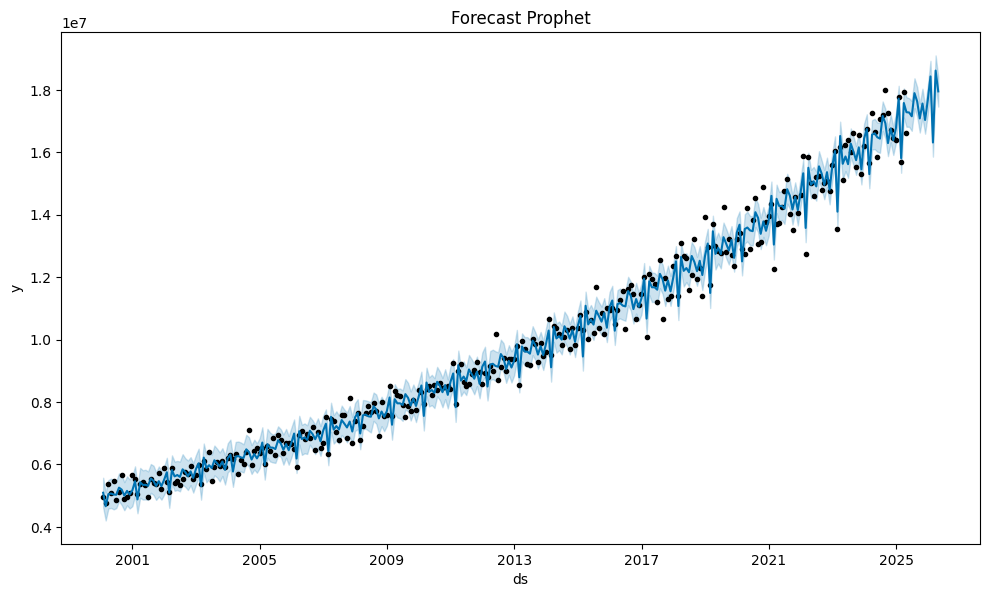

In [ ]:
from prophet import Prophet
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# 1. PREPARAR DATOS
# =========================
df_prophet = df_mensual.rename(columns={
    'FECHA': 'ds',
    'VENTAS': 'y'
})

df_prophet = df_prophet[['ds', 'y']].copy()

# asegurar formato datetime
df_prophet['ds'] = pd.to_datetime(
    df_prophet['ds']
)

# =========================
# 2. TRAIN / TEST
# =========================
meses_test = 12

train = df_prophet.iloc[:-meses_test].copy()

test = df_prophet.iloc[-meses_test:].copy()

# =========================
# 3. MODELO PROPHET
# =========================
modelo = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

modelo.fit(train)

# =========================
# 4. FUTURO
# =========================
future = modelo.make_future_dataframe(
    periods=meses_test,
    freq='M'
)

forecast = modelo.predict(future)

# =========================
# 5. PREDICCIONES TEST
# =========================
pred_test = forecast.tail(meses_test)

y_true = test['y'].values

y_pred = pred_test['yhat'].values

# =========================
# 6. MÉTRICAS
# =========================
rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

mae = mean_absolute_error(
    y_true,
    y_pred
)

r2 = r2_score(
    y_true,
    y_pred
)

# =========================
# 7. RESULTADOS
# =========================
print("\n============================")
print("MÉTRICAS PROPHET")
print("============================")

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2   : {r2:.4f}")

# =========================
# 8. DATAFRAME RESULTADOS
# =========================
resultados_prophet = pd.DataFrame({

    "Fecha": test['ds'],
    "Real": y_true,
    "Prediccion": y_pred,
    "Lower_95": pred_test['yhat_lower'].values,
    "Upper_95": pred_test['yhat_upper'].values

})

print(resultados_prophet)

# =========================
# 9. GUARDAR RESULTADOS
# =========================
modelo_resultado = pd.DataFrame([{

    "Modelo": "Prophet",
    "Optimizacion": "Ninguna",
    "Tipo_Backtesting": "Train_Test",
    "Steps": meses_test,
    "N_Backtesting": meses_test,
    "Error": None,
    "Trend": "Automatico",
    "Seasonal": "Yearly_Multiplicative",
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2

}])

csv_file = "mejor_modelo_ets.csv"

try:

    existing_df = pd.read_csv(csv_file)

    updated_df = pd.concat(
        [existing_df, modelo_resultado],
        ignore_index=True
    )

    updated_df = updated_df.sort_values(
        by=["R2", "RMSE"],
        ascending=[False, True]
    )

    updated_df.to_csv(
        csv_file,
        index=False
    )

except:

    modelo_resultado.to_csv(
        csv_file,
        index=False
    )

print("\nCSV ACTUALIZADO:")
print(csv_file)

# =========================
# 10. GUARDAR PREDICCIONES
# =========================
resultados_prophet.to_csv(
    "predicciones_prophet.csv",
    index=False
)

print("\nCSV PREDICCIONES:")
print("predicciones_prophet.csv")

# =========================
# 11. GRÁFICO
# =========================
fig = modelo.plot(forecast)

plt.title("Forecast Prophet")

plt.grid()

plt.show()


MÉTRICAS PROPHET
RMSE : 582253.1108
MAE  : 448770.7374
R2   : 0.1492
        Fecha        Real    Prediccion      Lower_95      Upper_95
0  2025-05-31  17487369.0  1.729958e+07  1.682591e+07  1.781107e+07
1  2025-06-30  17281766.0  1.712976e+07  1.661110e+07  1.765859e+07
2  2025-07-31  16939448.0  1.760943e+07  1.715043e+07  1.810865e+07
3  2025-08-31  17640091.0  1.754958e+07  1.707480e+07  1.805468e+07
4  2025-09-30  17293252.0  1.720169e+07  1.671750e+07  1.769754e+07
5  2025-10-31  18440148.0  1.755013e+07  1.706327e+07  1.804716e+07
6  2025-11-30  16171227.0  1.728317e+07  1.679179e+07  1.778689e+07
7  2025-12-31  17895030.0  1.767273e+07  1.717768e+07  1.816723e+07
8  2026-01-31  18242407.0  1.809072e+07  1.757506e+07  1.855763e+07
9  2026-02-28  17855165.0  1.699529e+07  1.651633e+07  1.749907e+07
10 2026-03-31  18386051.0  1.825767e+07  1.775178e+07  1.873002e+07
11 2026-04-30  17129235.0  1.795843e+07  1.748417e+07  1.846892e+07

CSV ACTUALIZADO:
mejor_modelo_ets.csv

CSV PR

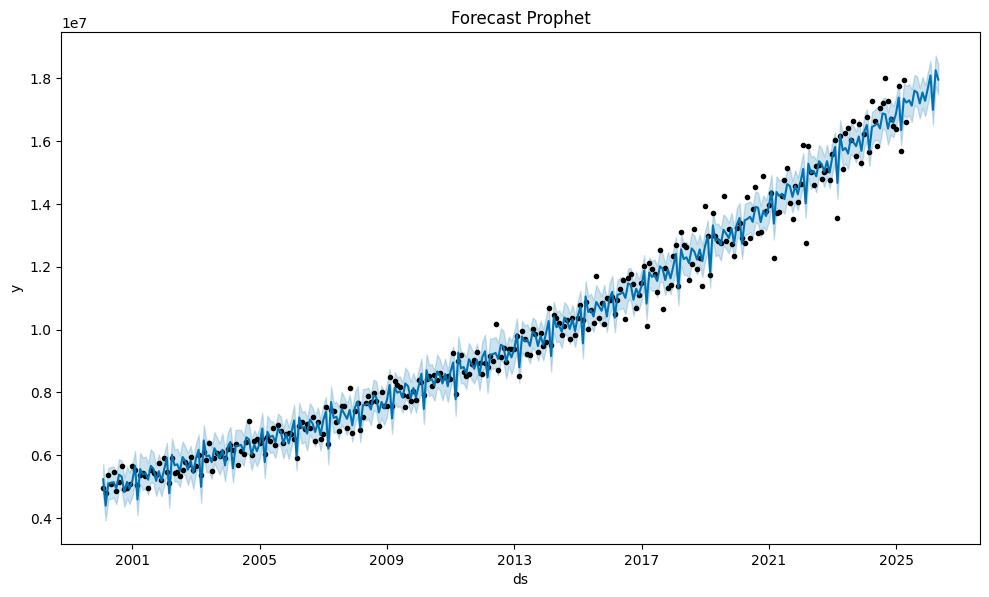

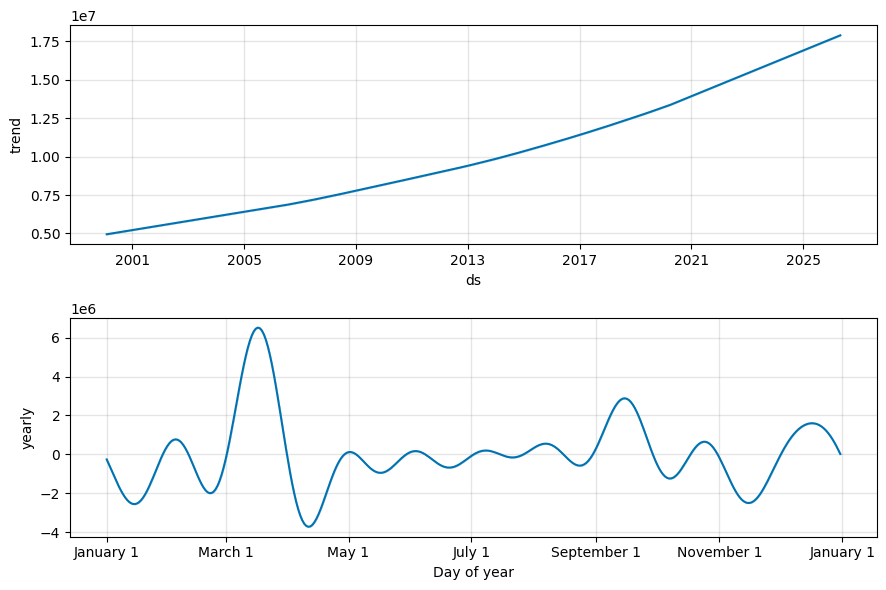

In [ ]:
from prophet import Prophet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# 1. PREPARAR DATOS
# =========================
df_prophet = df_mensual.rename(columns={
    'FECHA': 'ds',
    'VENTAS': 'y'
})

df_prophet = df_prophet[['ds', 'y']].copy()

df_prophet['ds'] = pd.to_datetime(
    df_prophet['ds']
)

# =========================
# 2. TRAIN / TEST
# =========================
meses_test = 12

train = df_prophet.iloc[:-meses_test].copy()

test = df_prophet.iloc[-meses_test:].copy()

# =========================
# 3. MODELO PROPHET
# =========================
model = Prophet(

    yearly_seasonality=True,

    weekly_seasonality=False,

    daily_seasonality=False,

    seasonality_mode='additive'

)

# entrenamiento
model.fit(train)

# =========================
# 4. FUTURO
# =========================
future = model.make_future_dataframe(
    periods=meses_test,
    freq='M'
)

forecast = model.predict(future)

# =========================
# 5. PREDICCIONES TEST
# =========================
forecast_test = forecast.tail(
    meses_test
)

y_true = test['y'].values

y_pred = forecast_test['yhat'].values

# =========================
# 6. MÉTRICAS
# =========================
rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

mae = mean_absolute_error(
    y_true,
    y_pred
)

r2 = r2_score(
    y_true,
    y_pred
)

# =========================
# 7. RESULTADOS
# =========================
print("\n============================")
print("MÉTRICAS PROPHET")
print("============================")

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2   : {r2:.4f}")

# =========================
# 8. DATAFRAME RESULTADOS
# =========================
resultados_prophet = pd.DataFrame({

    "Fecha": forecast_test['ds'].values,
    "Real": y_true,
    "Prediccion": y_pred,
    "Lower_95": forecast_test['yhat_lower'].values,
    "Upper_95": forecast_test['yhat_upper'].values

})

print(resultados_prophet)

# =========================
# 9. GUARDAR RESULTADOS
# =========================
modelo_resultado = pd.DataFrame([{

    "Modelo": "Prophet",
    "Optimizacion": "Ninguna",
    "Tipo_Backtesting": "Train_Test",
    "Steps": meses_test,
    "N_Backtesting": meses_test,
    "Error": None,
    "Trend": "Automatico",
    "Seasonal": "Yearly_Additive",
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2

}])

csv_file = "mejor_modelo_ets.csv"

try:

    existing_df = pd.read_csv(csv_file)

    updated_df = pd.concat(
        [existing_df, modelo_resultado],
        ignore_index=True
    )

    updated_df = updated_df.sort_values(
        by=["R2", "RMSE"],
        ascending=[False, True]
    )

    updated_df.to_csv(
        csv_file,
        index=False
    )

except:

    modelo_resultado.to_csv(
        csv_file,
        index=False
    )

print("\nCSV ACTUALIZADO:")
print(csv_file)

# =========================
# 10. GUARDAR PREDICCIONES
# =========================
resultados_prophet.to_csv(
    "predicciones_prophet.csv",
    index=False
)

print("\nCSV PREDICCIONES:")
print("predicciones_prophet.csv")

# =========================
# 11. GRÁFICO FORECAST
# =========================
fig = model.plot(forecast)

plt.title(
    "Forecast Prophet"
)

plt.grid()

plt.show()

# =========================
# 12. COMPONENTES
# =========================
fig2 = model.plot_components(
    forecast
)

plt.show()

In [ ]:
import pandas as pd

# =========================
# 1. CARGAR RESULTADOS
# =========================
csv_file = "mejor_modelo_ets.csv"

df_resultados = pd.read_csv(csv_file)

# =========================
# 2. ORDENAR MODELOS
# =========================
df_resultados = df_resultados.sort_values(
    by=["R2", "RMSE"],
    ascending=[False, True]
).reset_index(drop=True)

# =========================
# 3. MOSTRAR TABLA
# =========================
print("\n============================")
print("TABLA COMPARATIVA DE MODELOS")
print("============================")

tabla = df_resultados[
    [
        "Modelo",
        "Optimizacion",
        "Tipo_Backtesting",
        "Trend",
        "Seasonal",
        "RMSE",
        "MAE",
        "R2"
    ]
]

print(tabla)

# =========================
# 4. MEJOR MODELO
# =========================
mejor_modelo = df_resultados.iloc[0]

# =========================
# 5. RESULTADO FINAL
# =========================
print("\n============================")
print("MODELO RECOMENDADO")
print("============================")

print(
    f"""
El mejor modelo para utilizar es:

Modelo              : {mejor_modelo['Modelo']}
Optimización        : {mejor_modelo['Optimizacion']}
Backtesting         : {mejor_modelo['Tipo_Backtesting']}
Trend               : {mejor_modelo['Trend']}
Seasonal            : {mejor_modelo['Seasonal']}

Métricas:
RMSE                : {mejor_modelo['RMSE']:.4f}
MAE                 : {mejor_modelo['MAE']:.4f}
R2                  : {mejor_modelo['R2']:.4f}
"""
)


TABLA COMPARATIVA DE MODELOS
                                               Modelo Optimizacion  \
0                               OLS_Linear_Regression      Ninguna   
1                                     OLS_Forecasting      Ninguna   
2                   OLS_Polinomial_Grado_6_Estacional      Ninguna   
3                  OLS_Forecasting_Polinomial_Grado_6      Ninguna   
4                              OLS_Polinomial_Grado_6      Ninguna   
5                                             Prophet      Ninguna   
6    ETS_BAYESIAN(Error=mul, Trend=mul, Seasonal=add)    Bayesiana   
7    ETS_BAYESIAN(Error=mul, Trend=mul, Seasonal=add)    Bayesiana   
8   ETS(Error=mul, Trend=mul, Seasonal=add, Damped...          NaN   
9    ETS_BAYESIAN(Error=mul, Trend=mul, Seasonal=add)    Bayesiana   
10   ETS_BAYESIAN(Error=mul, Trend=mul, Seasonal=add)    Bayesiana   
11   ETS_BAYESIAN(Error=mul, Trend=mul, Seasonal=add)    Bayesiana   
12            ETS(Error=mul, Trend=mul, Seasonal=add)  Grid 

In [ ]:
import pandas as pd

# =========================
# CARGAR RESULTADOS
# =========================
csv_file = "mejor_modelo_ets.csv"

df_resultados = pd.read_csv(csv_file)

# =========================
# ORDENAR MODELOS
# =========================
df_resultados = df_resultados.sort_values(
    by=["R2", "RMSE"],
    ascending=[False, True]
).reset_index(drop=True)

# =========================
# TABLA HORIZONTAL BONITA
# =========================
tabla = df_resultados[
    [
        "Modelo",
        "Optimizacion",
        "Tipo_Backtesting",
        "Trend",
        "Seasonal",
        "RMSE",
        "MAE",
        "R2"
    ]
]

# evitar truncamiento
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)

print("\n============================")
print("COMPARACIÓN DE MODELOS")
print("============================")

print(
    tabla.to_string(
        index=False,
        justify="center"
    )
)

# =========================
# MEJOR MODELO
# =========================
mejor = df_resultados.iloc[0]

print("\n============================")
print("MODELO RECOMENDADO")
print("============================")

print(f"""
👉 Modelo seleccionado: {mejor['Modelo']}

📊 Métricas:
RMSE : {mejor['RMSE']:.4f}
MAE  : {mejor['MAE']:.4f}
R2   : {mejor['R2']:.4f}

⚙️ Configuración:
Trend     : {mejor['Trend']}
Seasonal  : {mejor['Seasonal']}
Optimización: {mejor['Optimizacion']}
""")


COMPARACIÓN DE MODELOS
                        Modelo                        Optimizacion    Tipo_Backtesting          Trend               Seasonal           RMSE          MAE         R2   
                                OLS_Linear_Regression     Ninguna         Sin Backtesting                NaN                   NaN 7.950222e+05 6.439614e+05  0.955219
                                      OLS_Forecasting     Ninguna      Forecasting Lineal             Lineal                   NaN 7.950222e+05 6.439614e+05  0.955219
                    OLS_Polinomial_Grado_6_Estacional     Ninguna         Sin Backtesting Polinomial_Grado_6     Dummies_Mensuales 8.001099e+05 5.217334e+05  0.954644
                   OLS_Forecasting_Polinomial_Grado_6     Ninguna  Forecasting Polinomial Polinomial_Grado_6                   NaN 8.450291e+05 5.673827e+05  0.949409
                               OLS_Polinomial_Grado_6     Ninguna         Sin Backtesting Polinomial_Grado_6                   NaN 8.450291e+

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# 1. Preparar datos
# =========================

# Asegurar orden temporal
data = data.sort_values("FECHA")

y = data["VENTAS"]

# Variable tiempo
x = np.arange(1, len(data) + 1)

# Agregar constante
X = sm.add_constant(x)

# =========================
# 2. Modelo OLS
# =========================
modelo = sm.OLS(y, X)

modelo_fit = modelo.fit()

# =========================
# 3. Predicciones históricas
# =========================
predicciones = modelo_fit.predict(X)

# =========================
# 4. Métricas
# =========================
rmse = np.sqrt(
    mean_squared_error(y, predicciones)
)

mae = mean_absolute_error(
    y,
    predicciones
)

r2 = r2_score(
    y,
    predicciones
)

# =========================
# 5. Pronóstico MAYO
# =========================

# siguiente periodo
x_futuro = len(data) + 1

# estructura igual al entrenamiento
X_futuro = sm.add_constant(
    np.array([x_futuro]),
    has_constant='add'
)

# predicción
pronostico_mayo = modelo_fit.predict(X_futuro)[0]

# =========================
# 6. Mostrar resultados
# =========================
print(modelo_fit.summary())

print("\n============================")
print("MÉTRICAS DEL MODELO")
print("============================")

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2   : {r2:.4f}")

print("\n============================")
print("PRONÓSTICO")
print("============================")

print(f"Pronóstico para MAYO: {pronostico_mayo:.2f}")

# =========================
# 7. Guardar resultados CSV
# =========================
model_name = "OLS_Linear_Regression"

best_result_df = pd.DataFrame([{
    "Modelo": model_name,
    "Optimizacion": "Ninguna",
    "Tipo_Backtesting": "Sin Backtesting",
    "Steps": 1,
    "N_Backtesting": None,
    "Error": None,
    "Trend": "Lineal",
    "Seasonal": None,
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2,
    "Pronostico_Mayo": pronostico_mayo
}])

csv_file = "mejor_modelo_ets.csv"

try:

    existing_df = pd.read_csv(csv_file)

    updated_df = pd.concat(
        [existing_df, best_result_df],
        ignore_index=True
    )

    # ordenar por mejor R2
    updated_df = updated_df.sort_values(
        by=["R2", "RMSE"],
        ascending=[False, True]
    )

    updated_df.to_csv(
        csv_file,
        index=False
    )

except:

    best_result_df.to_csv(
        csv_file,
        index=False
    )

print("\nCSV ACTUALIZADO:")
print(csv_file)

                            OLS Regression Results                            
Dep. Variable:                 VENTAS   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     6698.
Date:                Sat, 30 May 2026   Prob (F-statistic):          7.66e-214
Time:                        14:57:57   Log-Likelihood:                -4741.6
No. Observations:                 316   AIC:                             9487.
Df Residuals:                     314   BIC:                             9495.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.793e+06   8.99e+04     42.173      0.0

In [ ]:
# ==============================================================================
# 7. PLANIFICACIÓN OPERATIVA (AJUSTADA A 22 DÍAS HÁBILES)
# ==============================================================================

print("\n============================")
print("PLANIFICACIÓN OPERATIVA")
print("============================")

# Extraemos el valor numérico del pronóstico (manejando si viene formateado o como float)
if isinstance(pronostico_mayo, str):
    # Por si viene de un string formateado "$ 7,925,826.00"
    pronostico_mayo_num = float(pronostico_mayo.replace('$', '').replace(',', '').strip())
else:
    pronostico_mayo_num = float(pronostico_mayo)

# Clasificación según el pronóstico mensual total
if pronostico_mayo_num <= 3000000:
    nivel_operacion = "Baja demanda"
    meseros = 2
    cocina = 2
    inventario = "60% del stock normal"
    estrategia = "Mantener inventario básico y reducir costos operativos."

elif pronostico_mayo_num <= 6000000:
    nivel_operacion = "Demanda media"
    meseros = 3
    cocina = 3
    inventario = "85% del stock normal"
    estrategia = "Incrementar abastecimiento y reforzar horarios pico."

elif pronostico_mayo_num <= 9000000:
    nivel_operacion = "Alta demanda"
    meseros = 4
    cocina = 3
    inventario = "100% del stock normal"
    estrategia = "Aumentar stock de insumos críticos y trabajar con personal completo."

else:
    nivel_operacion = "Demanda extraordinaria"
    meseros = 5
    cocina = 4
    inventario = "130% del stock normal"
    estrategia = "Aplicar compras extraordinarias y contratar personal temporal."

# Mostrar recomendaciones operativas base
print(f"Nivel operativo      : {nivel_operacion}")
print(f"Meseros requeridos   : {meseros} diarios")
print(f"Personal de cocina   : {cocina} diarios")
print(f"Compra de inventario : {inventario}")
print("\nEstrategia sugerida:")
print(estrategia)

# ==============================================================================
# INSUMOS ESTIMADOS (MENSUALES)
# ==============================================================================
print("\n============================")
print("INSUMOS ESTIMADOS (MES)")
print("============================")

precio_promedio_plato = 25000

# Platos proyectados en TODO el mes
platos_estimados_mes = pronostico_mayo_num / precio_promedio_plato

# Estimación de insumos requeridos para suplir el mes
kg_arroz_mes = platos_estimados_mes * 0.15
kg_pollo_mes = platos_estimados_mes * 0.20
bebidas_mes = platos_estimados_mes * 1

df_insumos = pd.DataFrame({
    "Insumo": ["Arroz (kg)", "Pollo (kg)", "Bebidas (unidades)"],
    "Cantidad_Estimada_Mes": [
        round(kg_arroz_mes, 2),
        round(kg_pollo_mes, 2),
        round(bebidas_mes, 0)
    ]
})
print(df_insumos)

# ==============================================================================
# COSTOS DE INVENTARIO (MENSUALES)
# ==============================================================================
print("\n============================")
print("COSTOS DE INVENTARIO (MES)")
print("============================")

precio_kg_arroz = 4000
precio_kg_pollo = 15000
precio_bebida = 3000

costo_arroz_mes = kg_arroz_mes * precio_kg_arroz
costo_pollo_mes = kg_pollo_mes * precio_kg_pollo
costo_bebidas_mes = bebidas_mes * precio_bebida

costo_total_inventario_mes = costo_arroz_mes + costo_pollo_mes + costo_bebidas_mes

df_costos_inventario = pd.DataFrame({
    "Concepto": ["Costo arroz", "Costo pollo", "Costo bebidas", "Costo total inventario"],
    "Valor": [
        round(costo_arroz_mes, 2),
        round(costo_pollo_mes, 2),
        round(costo_bebidas_mes, 2),
        round(costo_total_inventario_mes, 2)
    ]
})
print(df_costos_inventario)

# ==============================================================================
# COSTOS DE PERSONAL (ESCALADOS A 22 DÍAS OPERATIVOS)
# ==============================================================================
print("\n============================")
print("COSTOS DE PERSONAL (22 DÍAS)")
print("============================")

DIAS_LABORALES = 22
salario_diario = 60000

total_empleados_diarios = meseros + cocina

# Corrección de la distorsión: Multiplicamos el gasto diario por los 22 días hábiles reales del mes
costo_personal_diario = total_empleados_diarios * salario_diario
costo_personal_mensual = costo_personal_diario * DIAS_LABORALES

df_personal = pd.DataFrame({
    "Concepto": [
        "Meseros (Staff diario)",
        "Personal cocina (Staff diario)",
        "Total Nómina Diaria",
        "Días Operativos (L-V)",
        "Costo Total Personal (Mes)"
    ],
    "Valor": [
        meseros,
        cocina,
        costo_personal_diario,
        DIAS_LABORALES,
        costo_personal_mensual
    ]
})
print(df_personal)

# ==============================================================================
# RESUMEN FINANCIERO SANO
# ==============================================================================
print("\n============================")
print("RESUMEN FINANCIERO MENSUAL")
print("============================")

# Costos totales consolidados del mes completo
costo_operativo_total_mes = costo_total_inventario_mes + costo_personal_mensual

# Utilidad real estimada
utilidad_estimada_real = pronostico_mayo_num - costo_operativo_total_mes

df_resumen = pd.DataFrame({
    "Concepto": [
        "Pronóstico ventas (Mayo)",
        "Costo inventario total (Mes)",
        "Costo personal consolidado (22d)",
        "Costo operativo total",
        "Utilidad neta estimada"
    ],
    "Valor": [
        round(pronostico_mayo_num, 2),
        round(costo_total_inventario_mes, 2),
        round(costo_personal_mensual, 2),
        round(costo_operativo_total_mes, 2),
        round(utilidad_estimada_real, 2)
    ]
})

# Formatear la tabla final para que el negocio la lea con claridad en pesos
df_resumen["Valor_Formateado"] = df_resumen["Valor"].map(lambda x: f"$ {x:,.2f}")
print(df_resumen[["Concepto", "Valor_Formateado"]].to_string(index=False))


PLANIFICACIÓN OPERATIVA
Nivel operativo      : Demanda extraordinaria
Meseros requeridos   : 5 diarios
Personal de cocina   : 4 diarios
Compra de inventario : 130% del stock normal

Estrategia sugerida:
Aplicar compras extraordinarias y contratar personal temporal.

INSUMOS ESTIMADOS (MES)
               Insumo  Cantidad_Estimada_Mes
0          Arroz (kg)                  99.32
1          Pollo (kg)                 132.43
2  Bebidas (unidades)                 662.00

COSTOS DE INVENTARIO (MES)
                 Concepto       Valor
0             Costo arroz   397276.48
1             Costo pollo  1986382.41
2           Costo bebidas  1986382.41
3  Costo total inventario  4370041.30

COSTOS DE PERSONAL (22 DÍAS)
                         Concepto     Valor
0          Meseros (Staff diario)         5
1  Personal cocina (Staff diario)         4
2             Total Nómina Diaria    540000
3           Días Operativos (L-V)        22
4      Costo Total Personal (Mes)  11880000

RESUMEN FINANCI

In [ ]:
# ==============================================================================
# 7. PLANIFICACIÓN OPERATIVA E INVENTARIOS (ESCALA REAL DE GASEOSAS)
# ==============================================================================

print("\n============================")
print("PLANIFICACIÓN OPERATIVA")
print("============================")

if isinstance(pronostico_mayo, str):
    pronostico_mayo_num = float(pronostico_mayo.replace('$', '').replace(',', '').strip())
else:
    pronostico_mayo_num = float(pronostico_mayo)

# Clasificación del nivel operativo
if pronostico_mayo_num <= 3000000:
    nivel_operacion = "Baja demanda"
    meseros, cocina = 2, 2
elif pronostico_mayo_num <= 6000000:
    nivel_operacion = "Demanda media"
    meseros, cocina = 2, 3
elif pronostico_mayo_num <= 9000000:
    nivel_operacion = "Alta demanda"
    meseros, cocina = 3, 3
else:
    nivel_operacion = "Demanda extraordinaria"
    meseros, cocina = 3, 4

print(f"Nivel operativo      : {nivel_operacion}")
print(f"Meseros requeridos   : {meseros} diarios")
print(f"Personal de cocina   : {cocina} diarios")

# ==============================================================================
# INSUMOS Y CANTIDADES ESTIMADAS
# ==============================================================================
print("\n============================")
print("INSUMOS ESTIMADOS")
print("============================")

DIAS_LABORALES = 22
precio_promedio_plato = 25000

# Volumen de platos mensual basado en el pronóstico lineal
platos_estimados_mes = pronostico_mayo_num / precio_promedio_plato

# Cantidades físicas según recetas reales
kg_arroz_mes = platos_estimados_mes * 0.15
kg_pollo_mes = platos_estimados_mes * 0.12
kg_granos_mes = platos_estimados_mes * 0.05

# NUEVA POLÍTICA FIJA DE GASEOSAS
gaseosas_consumo_mes = 30        # La mitad del lote bimestral
gaseosas_compra_bimestre = 60    # Lote cerrado de compra

df_insumos = pd.DataFrame({
    "Insumo": [
        "Arroz (kg)",
        "Pollo (kg)",
        "Granos (kg)",
        "Gaseosas - Consumo Mes (unidades)",
        "Gaseosas - Compra Bimestral (unidades)"
    ],
    "Cantidad_Estimada": [
        round(kg_arroz_mes, 2),
        round(kg_pollo_mes, 2),
        round(kg_granos_mes, 2),
        gaseosas_consumo_mes,
        gaseosas_compra_bimestre
    ]
})
print(df_insumos.to_string(index=False))

# ==============================================================================
# COSTOS DE INVENTARIO CON GASEOSAS CORREGIDAS
# ==============================================================================
print("\n============================")
print("COSTOS DE INVENTARIO (MES)")
print("============================")

precio_kg_arroz = 4000
precio_kg_pollo = 12000
precio_kg_granos = 20000
costo_especias_dia = 10000

# Nuevos costos fijos de gaseosas según tu proveedor
costo_lote_gaseosas = 60000.00                                # Costo de las 60 unidades
costo_gaseosas_mes = (gaseosas_consumo_mes / gaseosas_compra_bimestre) * costo_lote_gaseosas # $30,000

# Costos operativos mensuales de cocina
costo_arroz_mes = kg_arroz_mes * precio_kg_arroz
costo_pollo_mes = kg_pollo_mes * precio_kg_pollo
costo_granos_mes = kg_granos_mes * precio_kg_granos
costo_especias_mes = costo_especias_dia * DIAS_LABORALES

# Costo de inventario total cargado a Mayo
costo_total_inventario_mes = (
    costo_arroz_mes + costo_pollo_mes + costo_granos_mes + costo_gaseosas_mes + costo_especias_mes
)

df_costos_inventario = pd.DataFrame({
    "Concepto": [
        "Costo Arroz",
        "Costo Pollo (Optimizado)",
        "Costo Granos",
        "Costo Especias (Fijo)",
        "Costo Gaseosas (Consumo Mes)",
        "Desembolso Gaseosas (Factura Total 2 Meses)",
        "COSTO TOTAL INVENTARIO MENSUAL"
    ],
    "Valor": [
        round(costo_arroz_mes, 2),
        round(costo_pollo_mes, 2),
        round(costo_granos_mes, 2),
        round(costo_especias_mes, 2),
        round(costo_gaseosas_mes, 2),
        round(costo_lote_gaseosas, 2),
        round(costo_total_inventario_mes, 2)
    ]
})
print(df_costos_inventario.to_string(index=False))

# ==============================================================================
# RESUMEN FINANCIERO INTEGRAL
# ==============================================================================
print("\n============================")
print("RESUMEN FINANCIERO MENSUAL")
print("============================")

salario_diario = 60000
total_empleados_diarios = meseros + cocina
costo_personal_mensual = (total_empleados_diarios * salario_diario) * DIAS_LABORALES

costo_operativo_total_mes = costo_total_inventario_mes + costo_personal_mensual
utilidad_estimada_real = pronostico_mayo_num - costo_operativo_total_mes

df_resumen = pd.DataFrame({
    "Concepto": [
        "Pronóstico ventas (Mayo)",
        "Costo inventario total (Mes)",
        "Costo personal consolidado (22d)",
        "Costo operativo total",
        "Utilidad neta estimada"
    ],
    "Valor": [
        round(pronostico_mayo_num, 2),
        round(costo_total_inventario_mes, 2),
        round(costo_personal_mensual, 2),
        round(costo_operativo_total_mes, 2),
        round(utilidad_estimada_real, 2)
    ]
})

df_resumen["Valor_Formateado"] = df_resumen["Valor"].map(lambda x: f"$ {x:,.2f}")
print(df_resumen[["Concepto", "Valor_Formateado"]].to_string(index=False))


PLANIFICACIÓN OPERATIVA
Nivel operativo      : Demanda extraordinaria
Meseros requeridos   : 3 diarios
Personal de cocina   : 4 diarios

INSUMOS ESTIMADOS
                                Insumo  Cantidad_Estimada
                            Arroz (kg)              99.32
                            Pollo (kg)              79.46
                           Granos (kg)              33.11
     Gaseosas - Consumo Mes (unidades)              30.00
Gaseosas - Compra Bimestral (unidades)              60.00

COSTOS DE INVENTARIO (MES)
                                   Concepto      Valor
                                Costo Arroz  397276.48
                   Costo Pollo (Optimizado)  953463.56
                               Costo Granos  662127.47
                      Costo Especias (Fijo)  220000.00
               Costo Gaseosas (Consumo Mes)   30000.00
Desembolso Gaseosas (Factura Total 2 Meses)   60000.00
             COSTO TOTAL INVENTARIO MENSUAL 2262867.51

RESUMEN FINANCIERO MENSUAL


In [ ]:
# ==============================================================================
# 7. PLANIFICACIÓN OPERATIVA E INVENTARIOS (MENÚ AMPLIADO Y COSTOS FIJOS)
# ==============================================================================

print("\n============================")
print("PLANIFICACIÓN OPERATIVA")
print("============================")

if isinstance(pronostico_mayo, str):
    pronostico_mayo_num = float(pronostico_mayo.replace('$', '').replace(',', '').strip())
else:
    pronostico_mayo_num = float(pronostico_mayo)

# Clasificación del nivel operativo
if pronostico_mayo_num <= 3000000:
    nivel_operacion = "Baja demanda"
    meseros, cocina = 2, 2
elif pronostico_mayo_num <= 6000000:
    nivel_operacion = "Demanda media"
    meseros, cocina = 2, 3
elif pronostico_mayo_num <= 9000000:
    nivel_operacion = "Alta demanda"
    meseros, cocina = 3, 3
else:
    nivel_operacion = "Demanda extraordinaria"
    meseros, cocina = 3, 4

print(f"Nivel operativo      : {nivel_operacion}")
print(f"Meseros requeridos   : {meseros} diarios")
print(f"Personal de cocina   : {cocina} diarios")

# ==============================================================================
# INSUMOS Y CANTIDADES ESTIMADAS
# ==============================================================================
print("\n============================")
print("INSUMOS ESTIMADOS")
print("============================")

DIAS_LABORALES = 22
precio_promedio_plato = 25000
MES_EVALUADO = 5  # Mayo (Mes Impar para control de gaseosas)

# Volumen de platos mensual basado en el pronóstico lineal
platos_estimados_mes = pronostico_mayo_num / precio_promedio_plato

# Cantidades físicas base (Recetas habituales)
kg_arroz_mes = platos_estimados_mes * 0.15
kg_pollo_mes = platos_estimados_mes * 0.12
kg_granos_mes = platos_estimados_mes * 0.05

# NUEVOS INSUMOS: Carne y Pescado
kg_carne_mes = platos_estimados_mes * 0.20   # Proporción de 20% sobre los platos estimados
kg_pescado_mes = kg_pollo_mes * 0.10         # 10% del total de kg del pollo

# Política fija de gaseosas (Lote se compra en meses pares)
gaseosas_consumo_mes = 30
gaseosas_compra_mes = 60 if MES_EVALUADO % 2 == 0 else 0

df_insumos = pd.DataFrame({
    "Insumo": [
        "Arroz (kg)",
        "Pollo (kg)",
        "Carne (kg)",        # Nuevo
        "Pescado (kg)",      # Nuevo
        "Granos (kg)",
        "Gaseosas - Consumo Mes (unidades)",
        "Gaseosas - Compra Real (unidades)"
    ],
    "Cantidad_Estimada": [
        round(kg_arroz_mes, 2),
        round(kg_pollo_mes, 2),
        round(kg_carne_mes, 2),
        round(kg_pescado_mes, 2),
        round(kg_granos_mes, 2),
        gaseosas_consumo_mes,
        gaseosas_compra_mes
    ]
})
print(df_insumos.to_string(index=False))

# ==============================================================================
# COSTOS DE INVENTARIO Y OPERACIÓN
# ==============================================================================
print("\n============================")
print("COSTOS DE INVENTARIO (MES)")
print("============================")

# Matriz de precios unitarios actualizados
precio_kg_arroz = 4000
precio_kg_pollo = 12000
precio_kg_carne = 10000       # Nuevo
precio_kg_pescado = 16000     # Nuevo
precio_kg_granos = 20000
costo_especias_dia = 10000
VALOR_LOTE_GASEOSAS = 60000.00

# Costos mensuales calculados
costo_arroz_mes = kg_arroz_mes * precio_kg_arroz
costo_pollo_mes = kg_pollo_mes * precio_kg_pollo
costo_carne_mes = kg_carne_mes * precio_kg_carne
costo_pescado_mes = kg_pescado_mes * precio_kg_pescado
costo_granos_mes = kg_granos_mes * precio_kg_granos
costo_especias_mes = costo_especias_dia * DIAS_LABORALES

# Lógica bimestral de Gaseosas (Mayo es impar = $0)
costo_gaseosas_este_mes = VALOR_LOTE_GASEOSAS if MES_EVALUADO % 2 == 0 else 0.00
nota_gaseosas = "Mes Par" if MES_EVALUADO % 2 == 0 else "Uso Stock - Mes Impar"

# Sumatoria total del inventario de materia prima
costo_total_inventario_mes = (
    costo_arroz_mes + costo_pollo_mes + costo_carne_mes +
    costo_pescado_mes + costo_granos_mes + costo_gaseosas_este_mes + costo_especias_mes
)

df_costos_inventario = pd.DataFrame({
    "Concepto": [
        "Costo Arroz",
        "Costo Pollo",
        "Costo Carne (20% pro.)",
        "Costo Pescado (10% del pollo)",
        "Costo Granos",
        "Costo Especias (Fijo)",
        f"Costo Gaseosas ({nota_gaseosas})",
        "COSTO TOTAL INVENTARIO MENSUAL"
    ],
    "Valor": [
        round(costo_arroz_mes, 2),
        round(costo_pollo_mes, 2),
        round(costo_carne_mes, 2),
        round(costo_pescado_mes, 2),
        round(costo_granos_mes, 2),
        round(costo_especias_mes, 2),
        round(costo_gaseosas_este_mes, 2),
        round(costo_total_inventario_mes, 2)
    ]
})
print(df_costos_inventario.to_string(index=False))

# ==============================================================================
# RESUMEN FINANCIERO INTEGRAL (INCLUYE GASTOS DE FUNCIONAMIENTO)
# ==============================================================================
print("\n============================")
print("RESUMEN FINANCIERO MENSUAL")
print("============================")

# Personal
salario_diario = 60000
total_empleados_diarios = meseros + cocina
costo_personal_mensual = (total_empleados_diarios * salario_diario) * DIAS_LABORALES

# Gastos de funcionamiento fijos (Gas y Servicios Públicos)
gastos_funcionamiento_mes = 500000.00

# Consolidación final de egresos
costo_operativo_total_mes = costo_total_inventario_mes + costo_personal_mensual + gastos_funcionamiento_mes
utilidad_estimada_real = pronostico_mayo_num - costo_operativo_total_mes

df_resumen = pd.DataFrame({
    "Concepto": [
        "Pronóstico ventas (Mayo)",
        "Costo inventario total (Mes)",
        "Costo personal consolidado (22d)",
        "Gastos funcionamiento (Gas y Servicios)",
        "Costo operativo total",
        "Utilidad neta estimada"
    ],
    "Valor": [
        round(pronostico_mayo_num, 2),
        round(costo_total_inventario_mes, 2),
        round(costo_personal_mensual, 2),
        round(gastos_funcionamiento_mes, 2),
        round(costo_operativo_total_mes, 2),
        round(utilidad_estimada_real, 2)
    ]
})

df_resumen["Valor_Formateado"] = df_resumen["Valor"].map(lambda x: f"$ {x:,.2f}")
print(df_resumen[["Concepto", "Valor_Formateado"]].to_string(index=False))


PLANIFICACIÓN OPERATIVA
Nivel operativo      : Demanda extraordinaria
Meseros requeridos   : 3 diarios
Personal de cocina   : 4 diarios

INSUMOS ESTIMADOS
                           Insumo  Cantidad_Estimada
                       Arroz (kg)              99.32
                       Pollo (kg)              79.46
                       Carne (kg)             132.43
                     Pescado (kg)               7.95
                      Granos (kg)              33.11
Gaseosas - Consumo Mes (unidades)              30.00
Gaseosas - Compra Real (unidades)               0.00

COSTOS DE INVENTARIO (MES)
                              Concepto      Valor
                           Costo Arroz  397276.48
                           Costo Pollo  953463.56
                Costo Carne (20% pro.) 1324254.94
         Costo Pescado (10% del pollo)  127128.47
                          Costo Granos  662127.47
                 Costo Especias (Fijo)  220000.00
Costo Gaseosas (Uso Stock - Mes Impar)    